In [ ]:
import os
!pip install supabase psycopg2-binary

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 56.8 MB/s eta 0:00:00


In [ ]:
from supabase import create_client, Client
from google.colab import userdata
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy

supabase_url = userdata.get('SUPABASE_URL')
supabase_key = userdata.get('SUPABASE_SERVICE_ROLE_KEY')
supabase: Client = create_client(supabase_url, supabase_key)
print("Connected to Supabase!")

Connected to Supabase!


In [ ]:
def build_feature_matrix(raw: pd.DataFrame, min_non_null_ratio: float) -> pd.DataFrame:
          if raw.empty:
              raise ValueError("No feature rows returned for this user/date range after filtering.")
          raw["feature_date"] = pd.to_datetime(raw["feature_date"]).dt.date
          # Pivot table to get features as columns and dates as index
          matrix = raw.pivot_table(
              index="feature_date",
              columns="feature_key",
              values="value_num",
              aggfunc="mean",
          ).sort_index()
          # Filter columns based on minimum non-null ratio
          min_non_null = max(1, int(len(matrix) * min_non_null_ratio))
          matrix = matrix.dropna(axis=1, thresh=min_non_null)

          if matrix.shape[1] < 2:
              raise ValueError(
                  "Not enough dense numeric features after filtering. Try a wider date range or lower MIN_NON_NULL_RATIO."
              )
          return matrix

In [ ]:
def matrix_user_csv (USER_ID, START_DATE='2026-01-29', END_DATE= '2026-03-26', CORR_METHOD='spearman', MIN_NON_NULL_RATIO= 0.2, TOP_K=20, FEATURE_KEYS=[]):
  USER_ID = USER_ID
  START_DATE = START_DATE
  END_DATE = END_DATE
  FEATURE_KEYS = FEATURE_KEYS
  CORR_METHOD = CORR_METHOD # pearson', 'spearman', or 'kendall'
  MIN_NON_NULL_RATIO = MIN_NON_NULL_RATIO #Drop features with non-null ratio below this threshold
  TOP_K = TOP_K # How many strongest pairs to print
  OUTPUT_DIR = Path('./analysis_outputs') # Directory for heatmap and CSV outputs
  print ("parameters defined successfully")

  try:
      query = supabase.table('daily_features1').select('feature_date, feature_key, value_num')\
          .eq('user_id', USER_ID)\
          .gte('feature_date', START_DATE)\
          .lte('feature_date', END_DATE)

      query = query.filter('value_num', 'is', 'not_null')

      if FEATURE_KEYS:
          query = query.in_('feature_key', FEATURE_KEYS)

      response = query.execute()
      raw_data = response.data

      if raw_data:
          raw_df = pd.DataFrame(raw_data)
          print(f"Fetched {len(raw_df)} rows from daily_features1.")
          print("Raw Data Head:")
          display(raw_df.head())
          try:
              feature_matrix = build_feature_matrix(raw_df.copy(), MIN_NON_NULL_RATIO)
              print("Feature Matrix Head:")
              display(feature_matrix.head())
              print(f"Feature matrix shape: {feature_matrix.shape}")
              feature_matrix.to_csv(f'feature_matrix_{USER_ID}.csv')
              return feature_matrix
          except ValueError as e:
              print(f"Error building feature matrix: {e}")
              feature_matrix = pd.DataFrame()

      else:
          print("No data returned from daily_features1 for the specified criteria.")
          raw_df = pd.DataFrame()
  except Exception as e:
      print(f"Error fetching data: {e}")
      raw_df = pd.DataFrame()


In [ ]:
def csv_to_matrix (file_name):
  #csv to df
  feature_dataframe = pd.read_csv(file_name)
  if 'feature_date' in feature_dataframe.columns:
      feature_dataframe = feature_dataframe.set_index('feature_date')
  feature_dataframe.index = pd.to_datetime(feature_dataframe.index)
  return feature_dataframe

In [ ]:
from numpy.matrixlib.defmatrix import matrix
matrix_user_csv(USER_ID ="bf8434ee-b495-4da4-96d0-d919c5b4a957")

parameters defined successfully
Fetched 1000 rows from daily_features1.
Raw Data Head:


,feature_date,feature_key,value_num
0,2026-01-29,sleep_duration_hours,5.683333
1,2026-01-29,sleep_efficiency,84.400000
2,2026-01-29,deep_ratio,19.900000
3,2026-01-29,rem_ratio,14.400000
4,2026-01-29,wake_ratio,18.500000


Feature Matrix Head:


feature_key,activity_calories,blood_oxygen_avg,bmr_calories,breakfast_logged,breathing_rate,caffeine_cups,calories_out,daily_checkin_streak,deep_ratio,dinner_logged,...,social_connectedness,steps,steps_vs_7d,stress,stress_volatility_7d,stress_vs_7d,total_water_ml,very_active_minutes,wake_ratio,workload
feature_date,,,,,,,,,,,,,,,,,,,,,
2026-01-29,1253.0,96.5,1475.0,1.0,18.8,0.0,2483.0,2.0,19.9,1.0,...,63.0,9404.0,8552.0,76.0,31.82,53.5,1050.0,NaN,18.5,57.0
2026-01-30,1091.0,96.8,1475.0,1.0,18.6,1.0,2324.0,3.0,19.0,0.0,...,100.0,9077.0,8727.0,25.0,27.87,44.0,350.0,NaN,16.5,36.0
2026-01-31,2888.0,97.4,1475.0,1.0,17.8,2.0,3819.0,4.0,22.6,1.0,...,38.0,22341.0,12131.0,21.0,25.50,38.2,2250.0,121.0,10.6,66.0
2026-02-01,761.0,96.7,1475.0,1.0,18.2,0.0,2056.0,5.0,18.3,1.0,...,88.0,6529.0,11010.0,71.0,26.50,44.8,1050.0,NaN,14.0,0.0
2026-02-02,1537.0,97.1,1475.0,1.0,17.2,1.0,2705.0,6.0,18.4,1.0,...,36.0,14174.0,11538.0,30.0,24.46,42.3,350.0,49.0,7.4,44.0


Feature matrix shape: (24, 44)


feature_key,activity_calories,blood_oxygen_avg,bmr_calories,breakfast_logged,breathing_rate,caffeine_cups,calories_out,daily_checkin_streak,deep_ratio,dinner_logged,...,social_connectedness,steps,steps_vs_7d,stress,stress_volatility_7d,stress_vs_7d,total_water_ml,very_active_minutes,wake_ratio,workload
feature_date,,,,,,,,,,,,,,,,,,,,,
2026-01-29,1253.0,96.5,1475.0,1.0,18.8,0.0,2483.0,2.0,19.9,1.0,...,63.0,9404.0,8552.0,76.0,31.82,53.5,1050.0,NaN,18.5,57.0
2026-01-30,1091.0,96.8,1475.0,1.0,18.6,1.0,2324.0,3.0,19.0,0.0,...,100.0,9077.0,8727.0,25.0,27.87,44.0,350.0,NaN,16.5,36.0
2026-01-31,2888.0,97.4,1475.0,1.0,17.8,2.0,3819.0,4.0,22.6,1.0,...,38.0,22341.0,12131.0,21.0,25.50,38.2,2250.0,121.0,10.6,66.0
2026-02-01,761.0,96.7,1475.0,1.0,18.2,0.0,2056.0,5.0,18.3,1.0,...,88.0,6529.0,11010.0,71.0,26.50,44.8,1050.0,NaN,14.0,0.0
2026-02-02,1537.0,97.1,1475.0,1.0,17.2,1.0,2705.0,6.0,18.4,1.0,...,36.0,14174.0,11538.0,30.0,24.46,42.3,350.0,49.0,7.4,44.0
2026-02-03,1140.0,97.0,1475.0,1.0,17.4,0.0,2353.0,7.0,25.2,1.0,...,100.0,12122.0,11621.0,15.0,24.60,38.4,500.0,NaN,7.8,52.0
2026-02-04,1640.0,NaN,1475.0,1.0,NaN,0.0,2778.0,8.0,NaN,1.0,...,100.0,17706.0,12382.0,31.0,22.93,37.5,1450.0,42.0,NaN,53.0
2026-02-05,1915.0,97.9,1475.0,1.0,17.0,1.0,3025.0,8.0,25.7,1.0,...,100.0,14144.0,13187.0,9.0,25.04,34.8,1500.0,51.0,8.8,8.0
2026-02-06,1066.0,97.5,1475.0,1.0,17.0,0.0,2327.0,8.0,19.2,1.0,...,12.0,10713.0,13351.0,16.0,19.23,27.2,1250.0,16.0,8.1,11.0


## Data Exploration

This section focuses on exploring the dataset to understand its characteristics, identify patterns, and visualize relationships between different features. We will use various plots to gain insights into the daily features for each user before proceeding with clustering analysis.

In [ ]:
# Lineplot between different features of the user
def lineplot_features(feature_matrix, USER_ID, save):
  feature_pairs = [
      ('sleep_duration_hours', 'overall_score'),
      ('sleep_efficiency', 'overall_score'),
      ('deep_ratio', 'overall_score'),
      ('rem_ratio', 'overall_score'),
      ('steps', 'overall_score'),
      ('total_active_minutes', 'overall_score'),
      ('very_active_minutes', 'overall_score'),
      ('sedentary_minutes', 'overall_score'),
      ('mood', 'overall_score'),
      ('stress', 'overall_score'),
      ('energy', 'overall_score'),
      ('focus', 'overall_score'),
      ('workload', 'overall_score'),
      ('sleep_restfulness', 'overall_score'),
      ('social_connectedness', 'overall_score'),
      ('emotions_count', 'overall_score'),
      ('bedtime_consistency_score', 'overall_score'),
      ('journal_word_count', 'overall_score'),
  ]

  if not feature_matrix.empty:
      for x_feature, y_feature in feature_pairs:
          # Ensure feature names are in lowercase to match common DataFrame column naming
          x_feature_lower = x_feature.lower()
          y_feature_lower = y_feature.lower()

          if x_feature_lower in feature_matrix.columns and y_feature_lower in feature_matrix.columns:
              plt.figure(figsize=(10, 6))
              sns.lineplot(x=feature_matrix[x_feature_lower], y=feature_matrix[y_feature_lower])
              plt.title(f'{x_feature.replace("_", " ").title()} vs. {y_feature.replace("_", " ").title()}')
              plt.xlabel(x_feature.replace("_", " ").title())
              plt.ylabel(y_feature.replace("_", " ").title())
              plt.grid(True)
              plt.tight_layout()
              plt.show()
              if save:
                OUTPUT_DIR = Path('./analysis_outputs')
                if not os.path.exists(OUTPUT_DIR):
                    os.makedirs(OUTPUT_DIR)
                plt.savefig(f'lineplot_wrt_date_{x_feature}_{y_feature}_{USER_ID}.png')
          else:
              print(f"Skipping plot for {x_feature} vs {y_feature}: one or both features not found in the feature matrix.")
  else:
      print("Feature matrix is empty, cannot generate scatter plots. Please ensure 'feature_matrix' is populated with data.")

In [ ]:
def lineplot_features_wrt_date(feature_matrix, USER_ID, save):
  feature_pairs = [
      ('sleep_duration_hours', 'overall_score'),
      ('sleep_efficiency', 'overall_score'),
      ('deep_ratio', 'overall_score'),
      ('rem_ratio', 'overall_score'),
      ('steps', 'overall_score'),
      ('total_active_minutes', 'overall_score'),
      ('very_active_minutes', 'overall_score'),
      ('sedentary_minutes', 'overall_score'),
      ('mood', 'overall_score'),
      ('stress', 'overall_score'),
      ('energy', 'overall_score'),
      ('focus', 'overall_score'),
      ('workload', 'overall_score'),
      ('sleep_restfulness', 'overall_score'),
      ('social_connectedness', 'overall_score'),
      ('emotions_count', 'overall_score'),
      ('bedtime_consistency_score', 'overall_score'),
      ('journal_word_count', 'overall_score'),
  ]

  if not feature_matrix.empty:
      for x_feature, y_feature in feature_pairs:
          x_feature_lower = x_feature.lower()
          y_feature_lower = y_feature.lower()
          x_feature_higher = y_feature.lower()

          if x_feature_lower in feature_matrix.columns and y_feature_lower in feature_matrix.columns:
              plt.figure(figsize=(10, 6))
              sns.lineplot(x=feature_matrix.index, y=feature_matrix[x_feature_lower], marker="D", color = "blue", label = x_feature_lower)
              sns.lineplot(x=feature_matrix.index, y=feature_matrix[y_feature_lower], marker="o", color="red", label = y_feature_lower)
              plt.legend()
              plt.title(f'{x_feature.replace("_", " ").title()} vs. {y_feature.replace("_", " ").title()}')
              plt.xlabel("Feature Date")
              plt.ylabel("Features")
              plt.grid(True)
              plt.tight_layout()
              plt.show()
              #save plots in a specific folder and directory
              if save:
                OUTPUT_DIR = Path('./analysis_outputs')
                if not os.path.exists(OUTPUT_DIR):
                    os.makedirs(OUTPUT_DIR)
                plt.savefig(f'lineplot_wrt_date_{x_feature}_{y_feature}_{USER_ID}.png')

          else:
              print(f"Skipping plot for {x_feature} vs {y_feature}: one or both features not found in the feature matrix.")
  else:
      print("Feature matrix is empty, cannot generate scatter plots. Please ensure 'feature_matrix' is populated with data.")

In [ ]:

#Line plots will help see how these values change over your selected date range, identifying trends, cycles, or sudden drops/spikes.
def multiple_feature_time_plot (feature_matrix, USER_ID, list_features, save):
  if not feature_matrix.empty:
      plt.figure(figsize=(15, 6))
      features_to_plot_ts = [col for col in list_features if col in feature_matrix.columns]

      if features_to_plot_ts:
          for feature in features_to_plot_ts:
              plt.plot(feature_matrix.index, feature_matrix[feature], label=feature)
          plt.title('Time-Series Trends for Key Features')
          plt.xlabel('Date')
          plt.ylabel('Value')
          plt.legend()
          plt.grid(True)
          plt.xticks(rotation=45)
          plt.tight_layout()
          plt.show()
          if save:
            OUTPUT_DIR = Path('./analysis_outputs')
            if not os.path.exists(OUTPUT_DIR):
                os.makedirs(OUTPUT_DIR)
                plt.savefig(f'time_series_plot_{USER_ID}_{list_features[:]}.png')
      else:
          print("Selected time-series features not found in the feature matrix.")
  else:
      print("Feature matrix is empty, cannot plot time-series trends.")

In [ ]:
#correlation heatmap of all the following features
def heatmap_features(feature_matrix, USER_ID, save, CORR_METHOD='spearman', MIN_NON_NULL_RATIO= 0.2, TOP_K=20,):
  available_features = feature_matrix.columns.tolist()
  MIN_PERIODS = int(len(feature_matrix) * MIN_NON_NULL_RATIO) #
  if not feature_matrix.empty:
      if len(available_features) < 2:
          print("Not enough available features to compute a correlation heatmap. Please ensure at least two features exist in the matrix.")
      else:
          filtered_feature_matrix = feature_matrix[available_features]

          try:
              # Calculate the correlation matrix for the filtered features
              specific_correlation_matrix = filtered_feature_matrix.corr(method=CORR_METHOD, min_periods=MIN_PERIODS)
              specific_correlation_matrix = specific_correlation_matrix.dropna(axis=0, how="all").dropna(axis=1, how="all")

              if not specific_correlation_matrix.empty:
                  print("Correlation Matrix for Requested Features:")
                  display(specific_correlation_matrix.head())
                  plt.figure(figsize=(max(12, specific_correlation_matrix.shape[1] * 0.6), max(10, specific_correlation_matrix.shape[0] * 0.5)))
                  sns.heatmap(
                      specific_correlation_matrix,
                      cmap="vlag",
                      center=0,
                      square=True,
                      linewidths=0.2,
                      cbar_kws={"shrink": 0.75},
                      annot=False)
                  plt.title(f"Feature Correlation Heatmap ({CORR_METHOD.capitalize()} Method) for all available features")
                  plt.tight_layout()
                  plt.show()
                  plt.close()
                  if save:
                    OUTPUT_DIR = Path('./analysis_outputs')
                    if not os.path.exists(OUTPUT_DIR):
                        os.makedirs(OUTPUT_DIR)
                    plt.savefig(f'heatmap_{USER_ID}.png')
              else:
                  print("Specific correlation matrix is empty after filtering.")

          except Exception as e:
              print(f"Error calculating correlation or generating heatmap for specific features: {e}")
  else:
      print("Feature matrix is empty, cannot generate correlation heatmap.")

In [ ]:
def get_plots_all (feature_matrix, USER_ID, save, CORR_METHOD='spearman', MIN_NON_NULL_RATIO= 0.2, TOP_K=20):
  lineplot_features(feature_matrix, USER_ID, save)
  lineplot_features_wrt_date(feature_matrix, USER_ID, save)
  heatmap_features(feature_matrix, USER_ID, save, CORR_METHOD='spearman')

In [ ]:
list_files=["/content/feature_matrix_bf8434ee-b495-4da4-96d0-d919c5b4a957.csv"]
matrix_key_1 = ["ameena"]

all_feature_matrices = {}

for file_name, matrix_key in zip(list_files, matrix_key_1):
  try:
    feature_matrix = csv_to_matrix(file_name)
    if not feature_matrix.empty:
      all_feature_matrices[matrix_key] = feature_matrix
      print(f"Successfully loaded and processed {file_name}. Matrix shape: {feature_matrix.shape}")
    else:
      print(f"No valid feature matrix generated for {file_name}.")
  except FileNotFoundError:
    print(f"Warning: File {file_name} not found. Skipping.")
  except Exception as e:
    print(f"Error processing {file_name}: {e}")

Successfully loaded and processed /content/feature_matrix_bf8434ee-b495-4da4-96d0-d919c5b4a957.csv. Matrix shape: (24, 44)


ba7806f0-d26f-4b9d-95d7-917d4159b638 and ameena


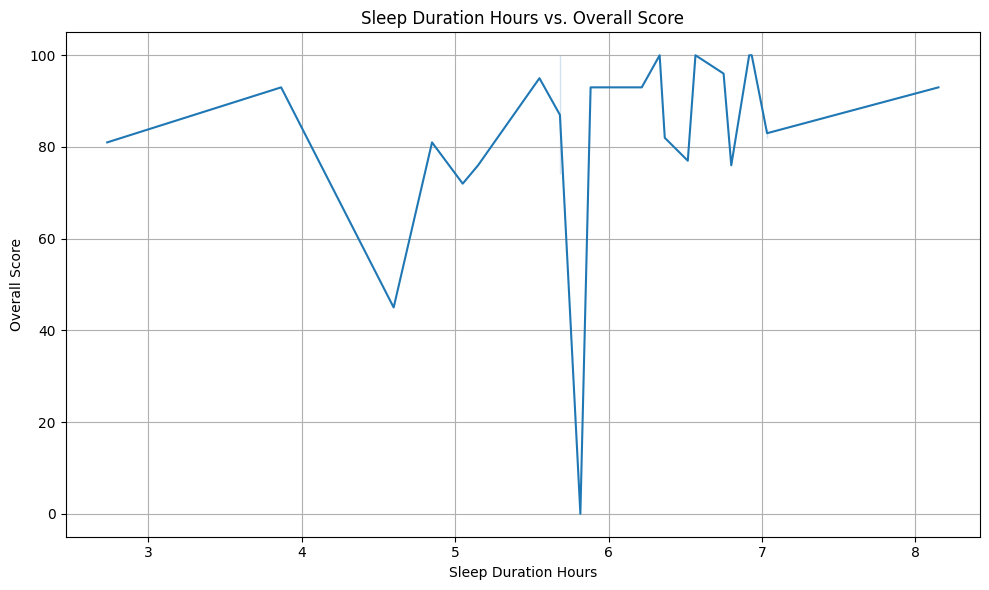

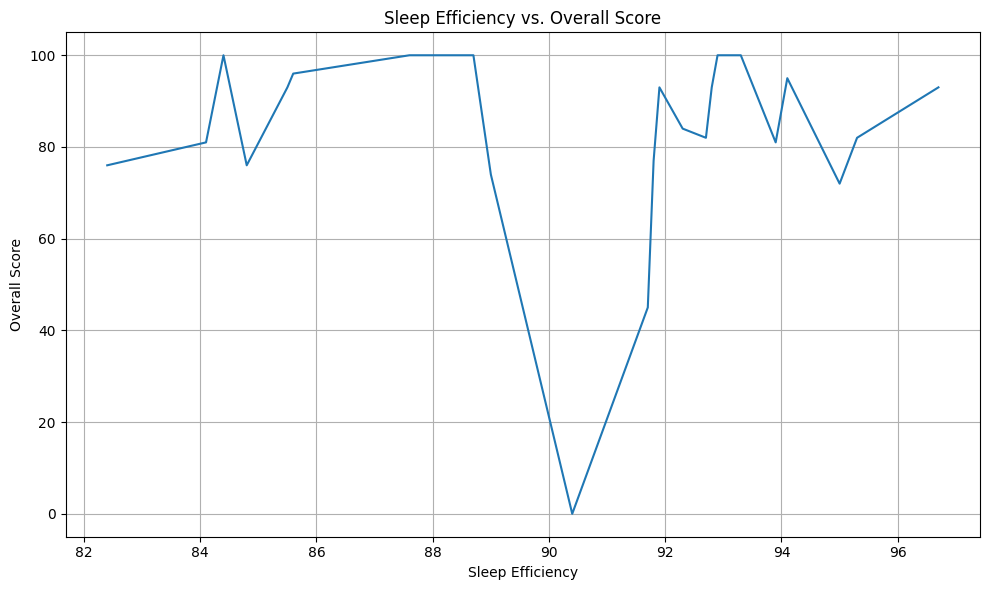

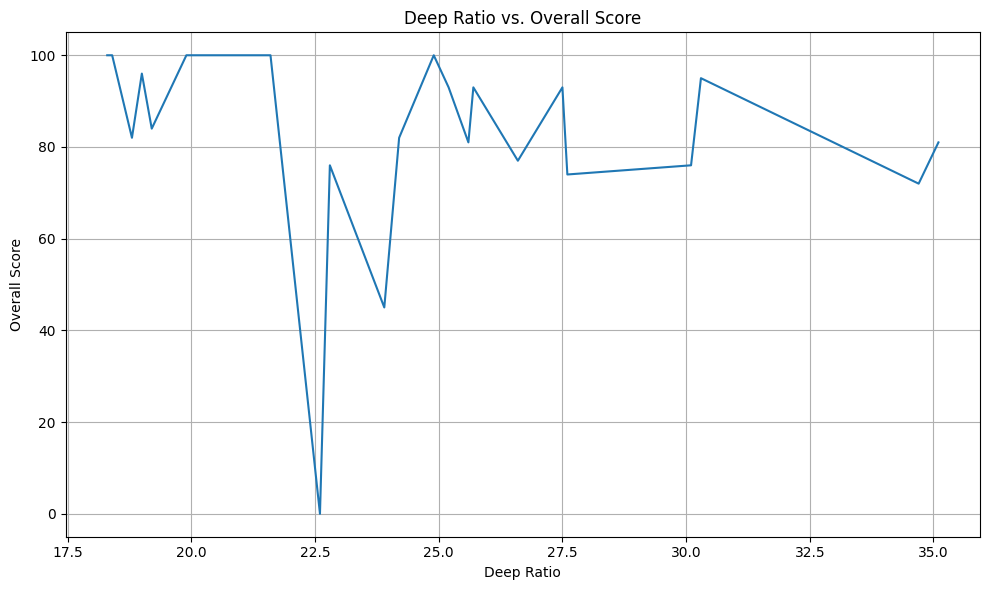

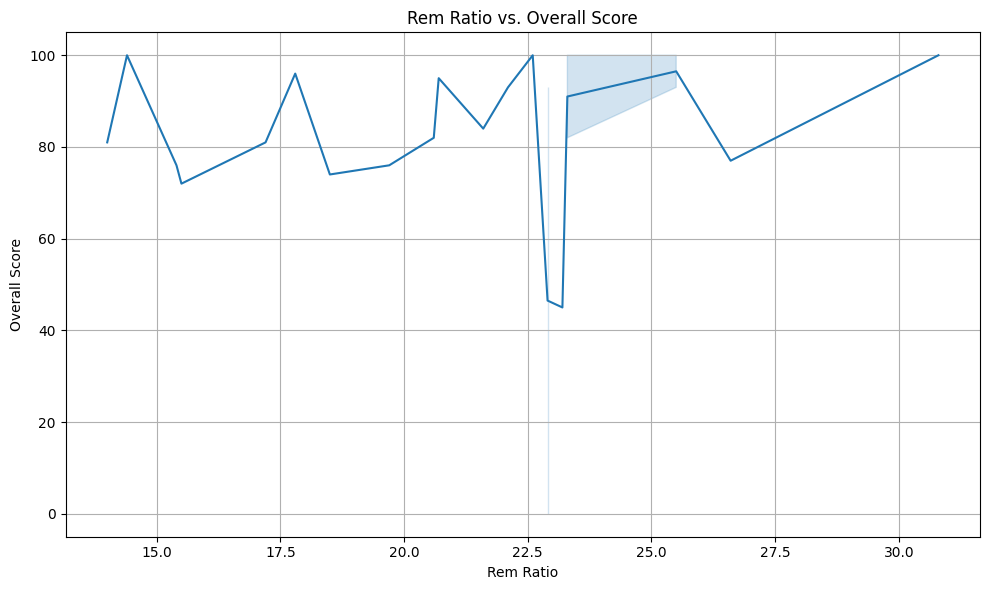

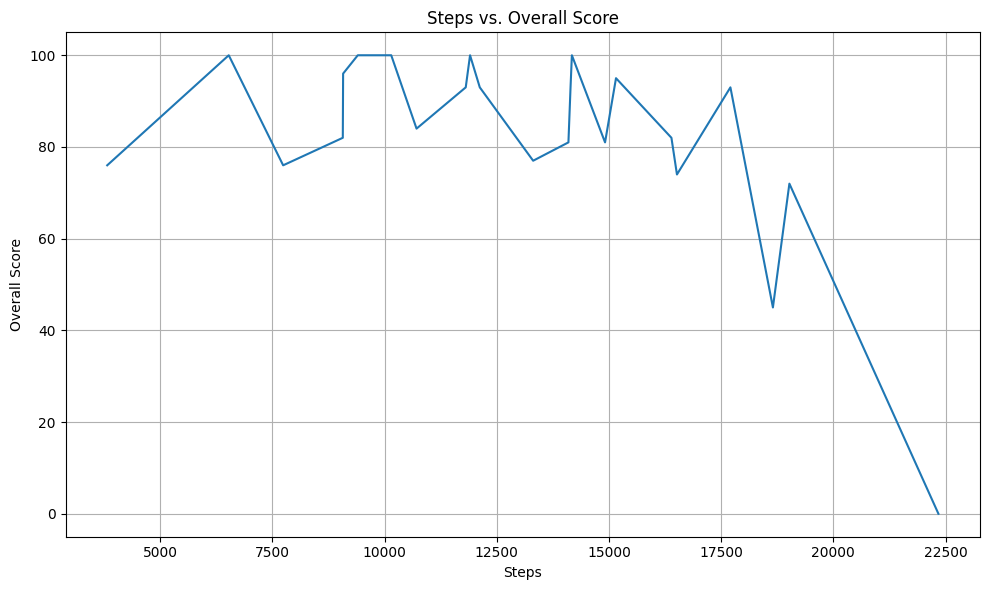

Skipping plot for total_active_minutes vs overall_score: one or both features not found in the feature matrix.


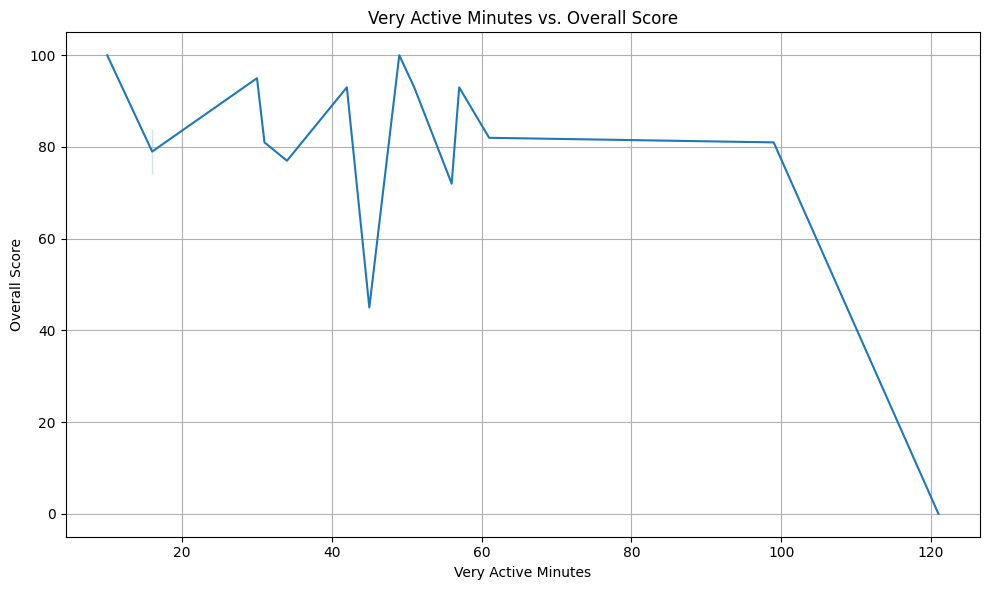

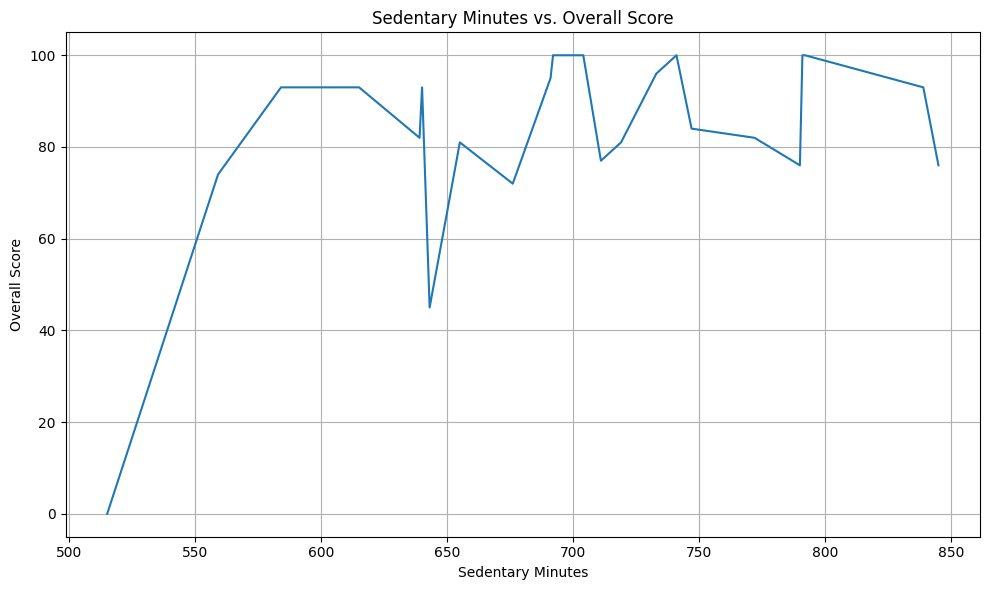

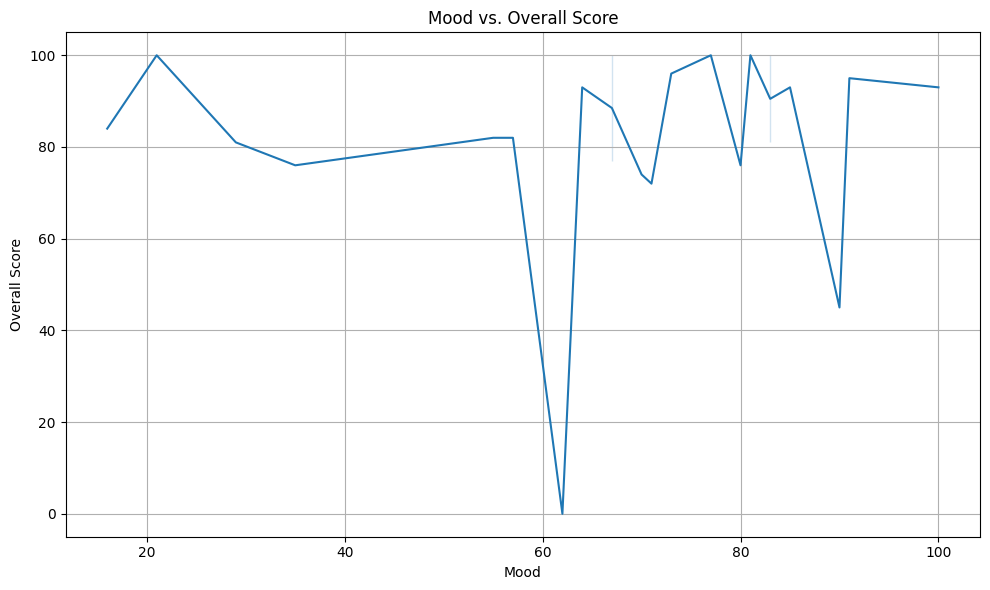

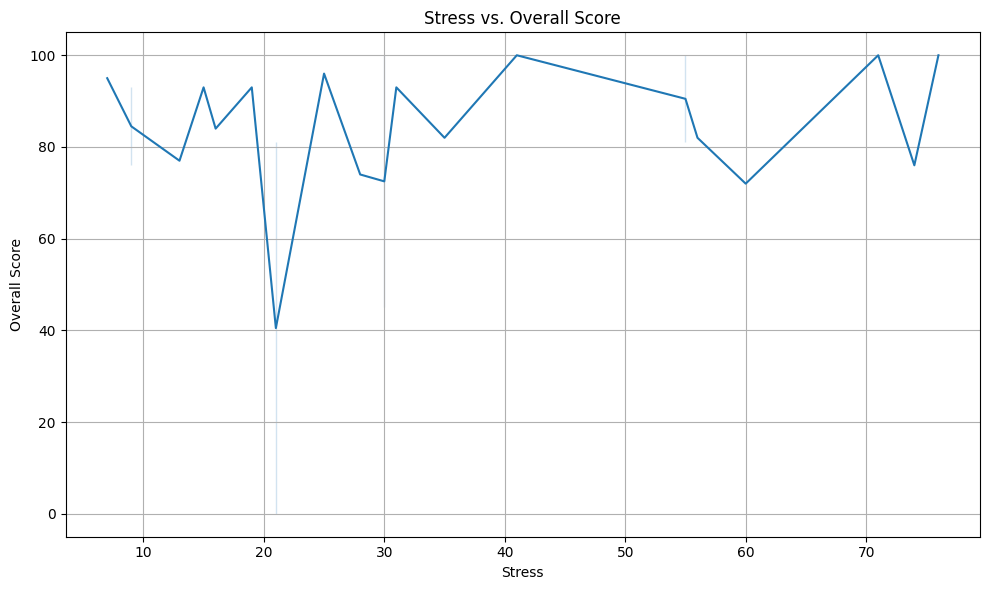

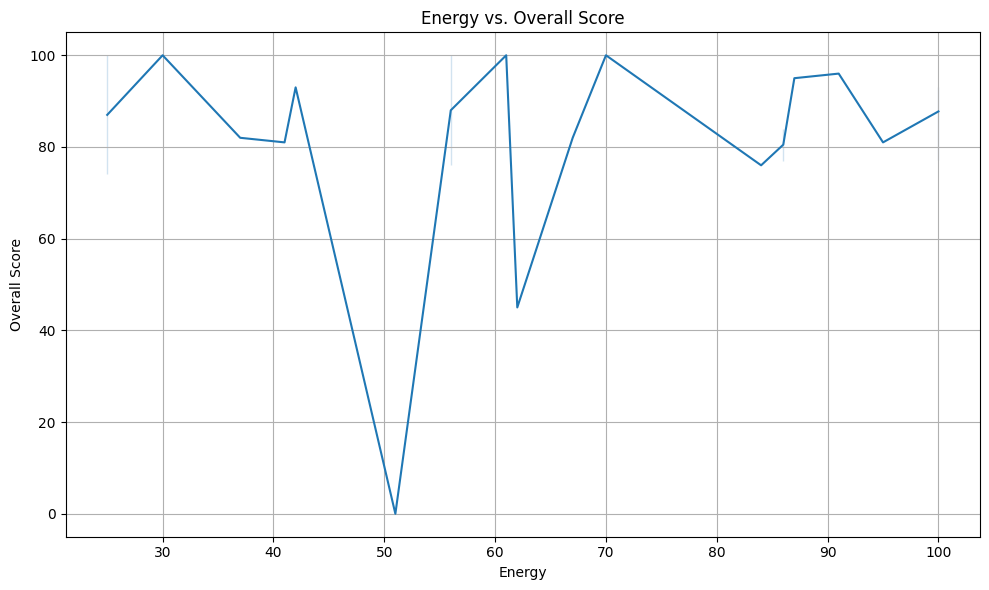

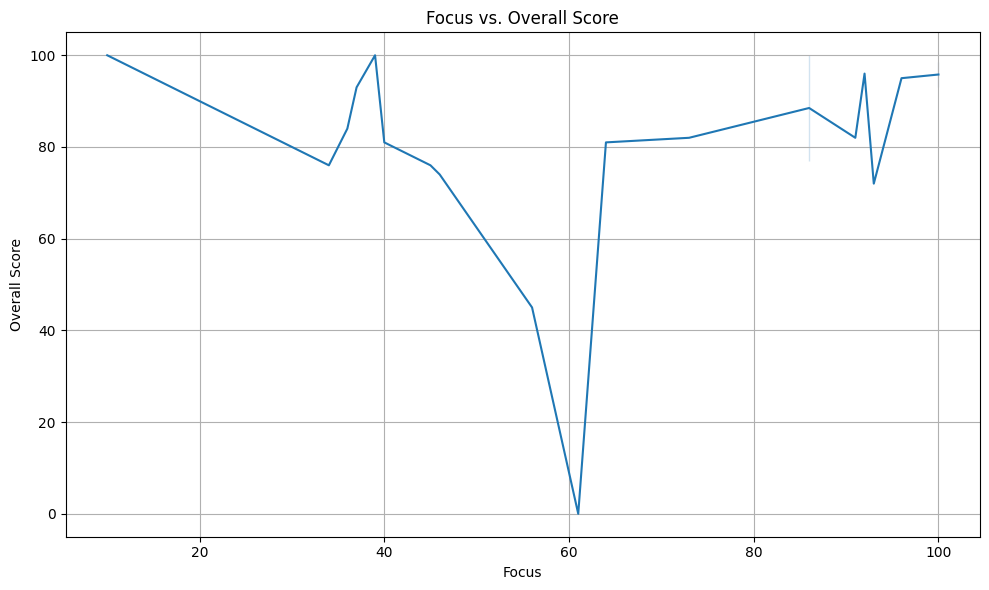

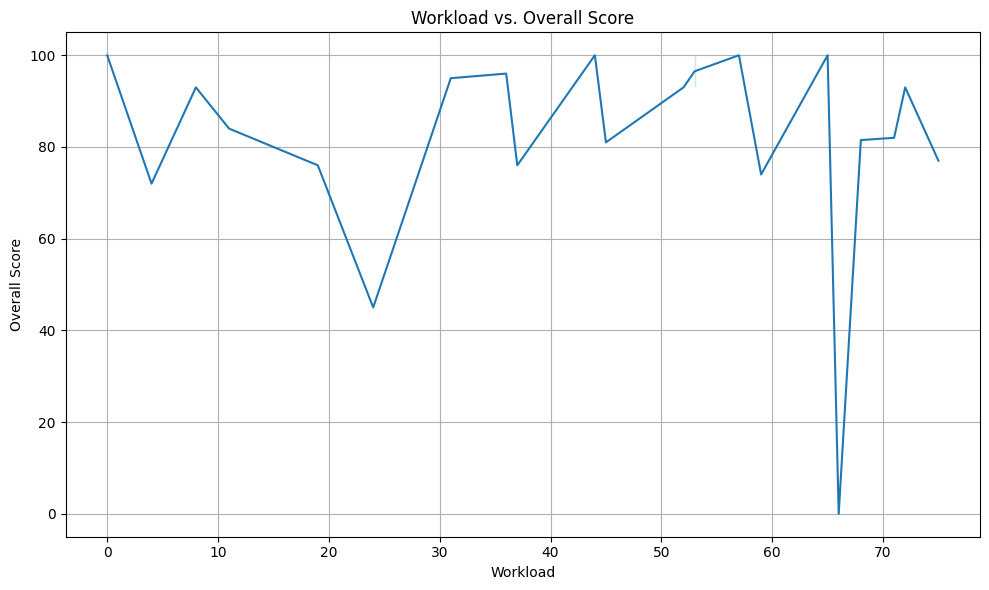

Skipping plot for sleep_restfulness vs overall_score: one or both features not found in the feature matrix.


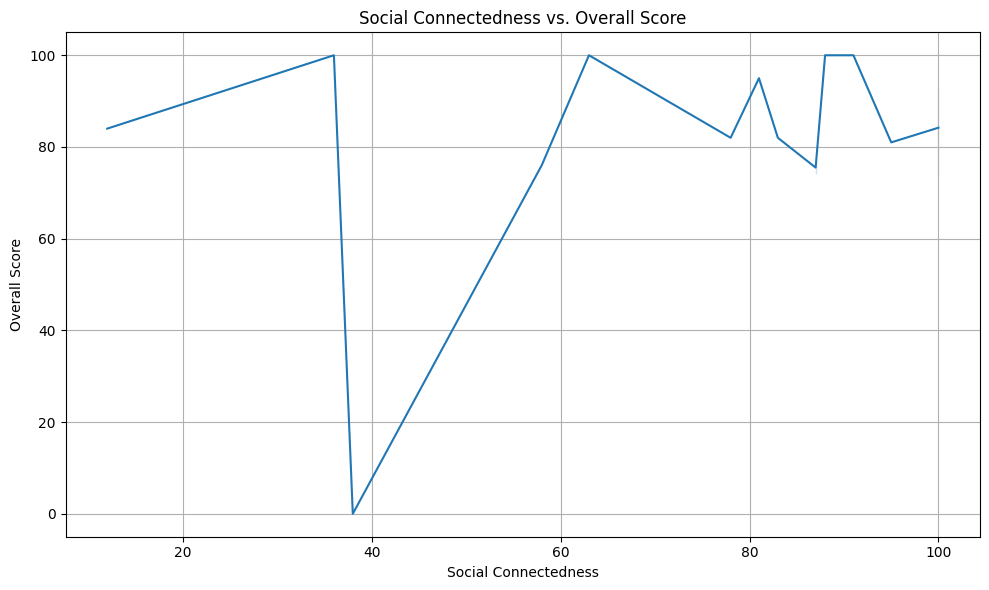

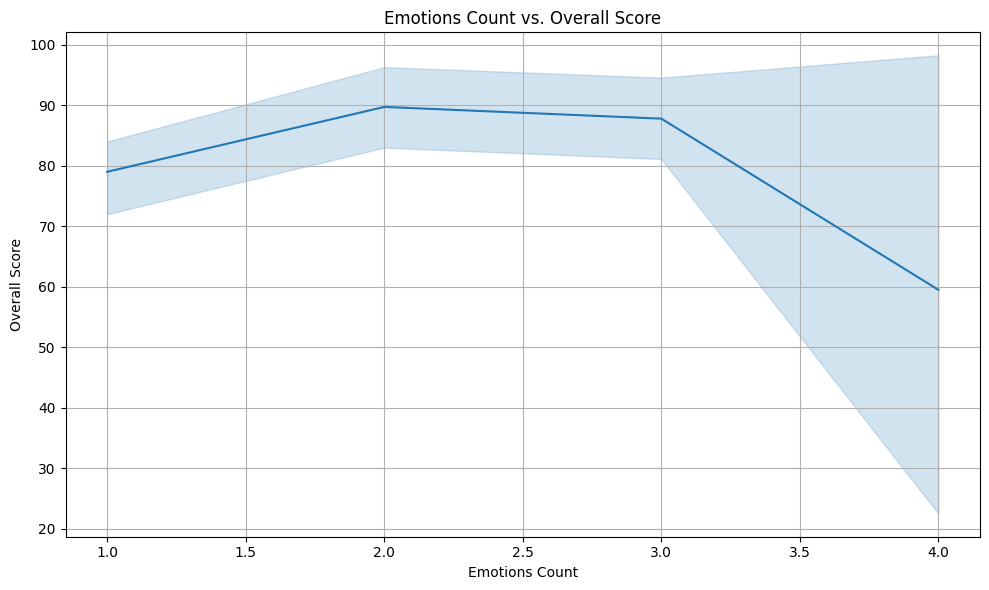

Skipping plot for bedtime_consistency_score vs overall_score: one or both features not found in the feature matrix.
Skipping plot for journal_word_count vs overall_score: one or both features not found in the feature matrix.


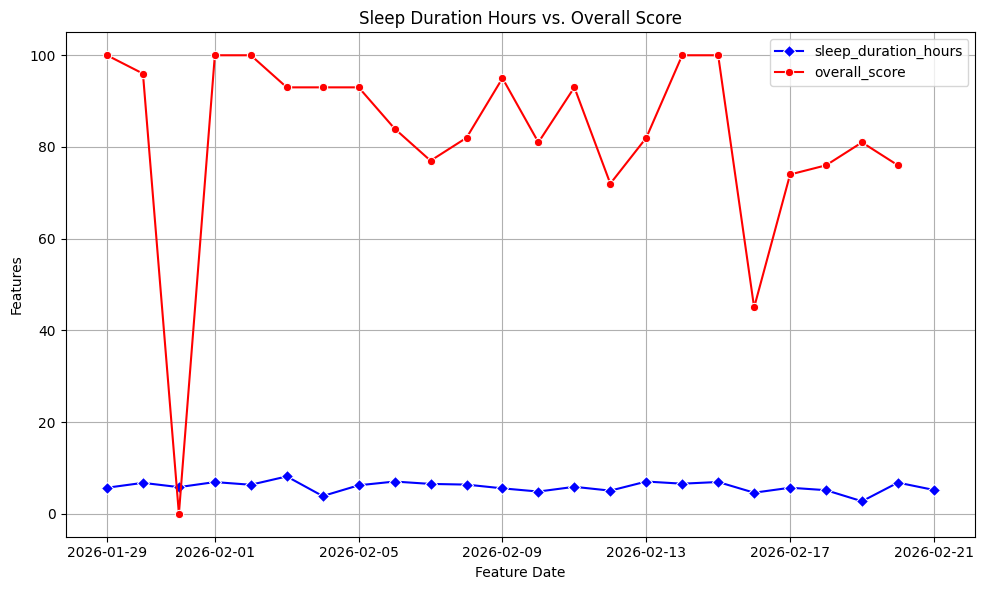

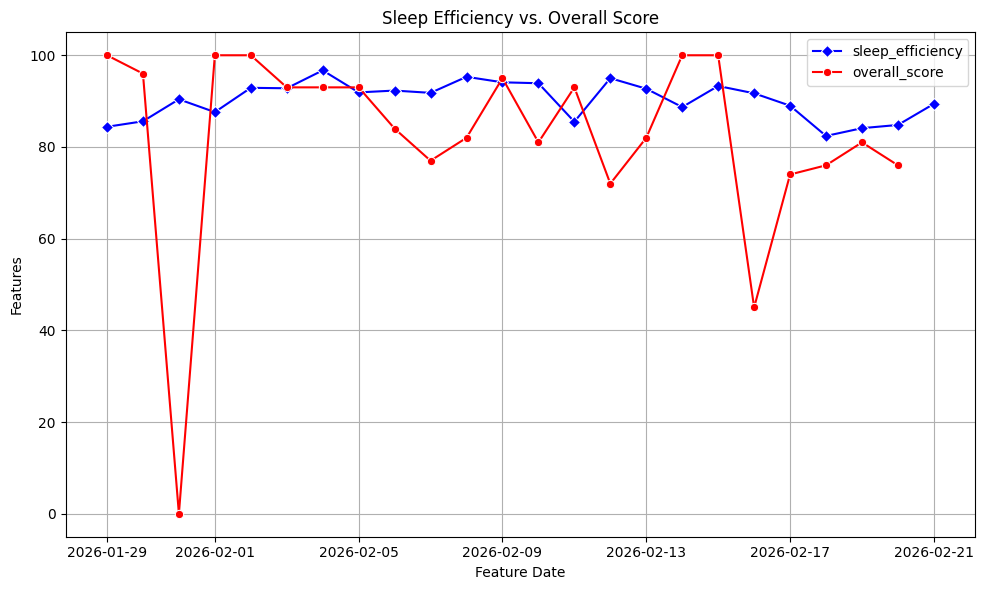

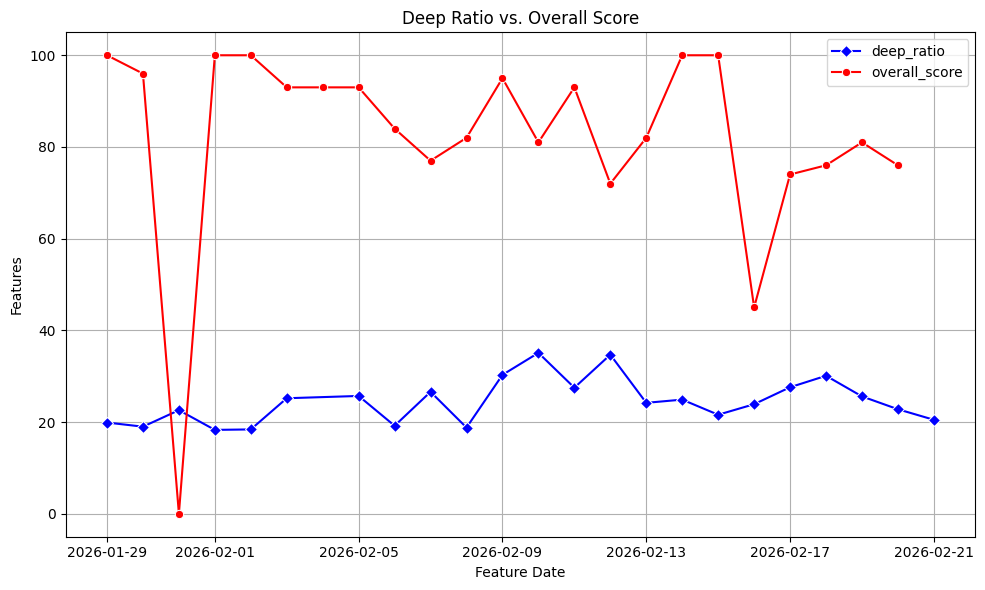

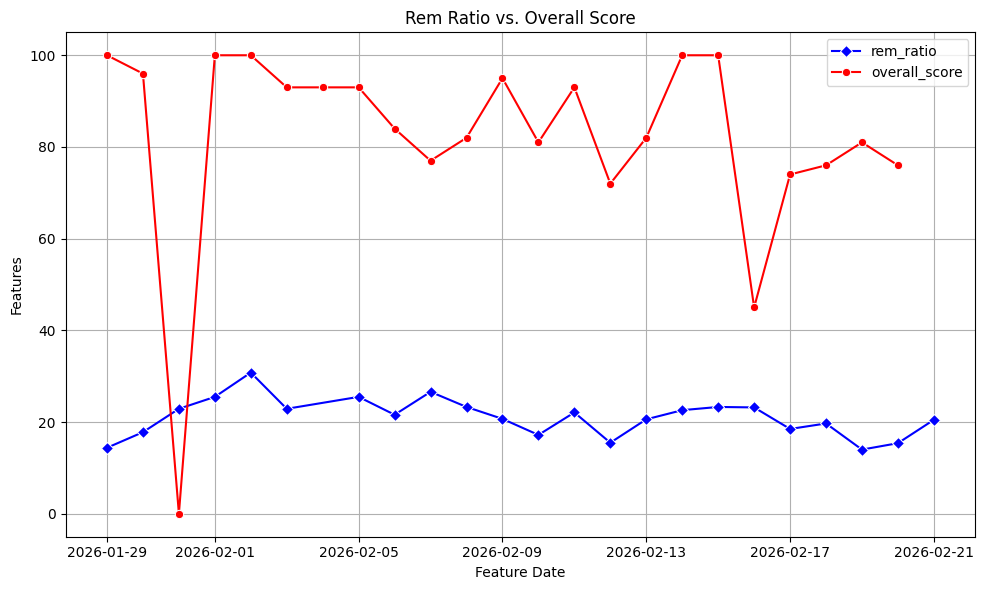

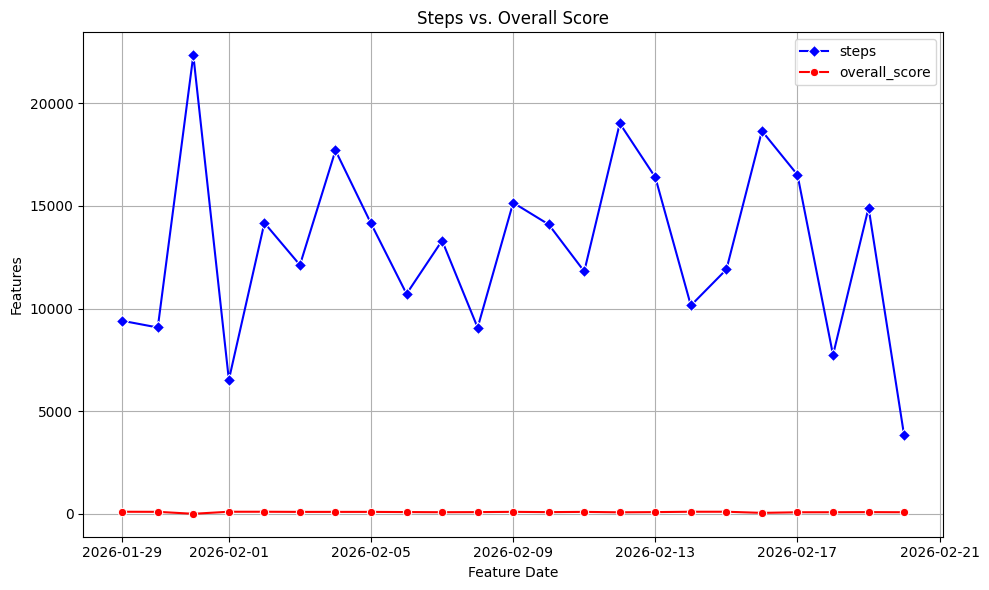

Skipping plot for total_active_minutes vs overall_score: one or both features not found in the feature matrix.


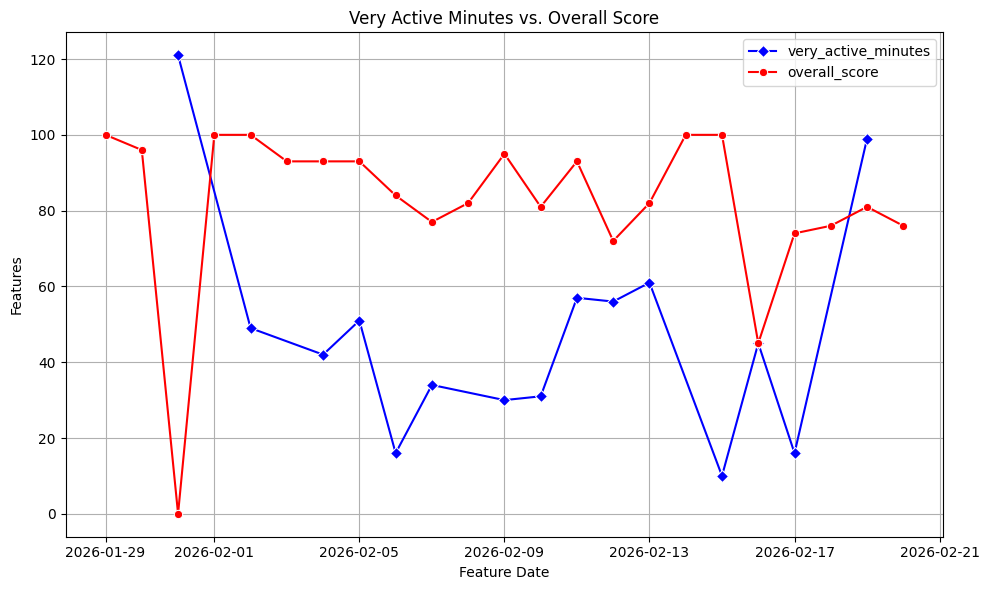

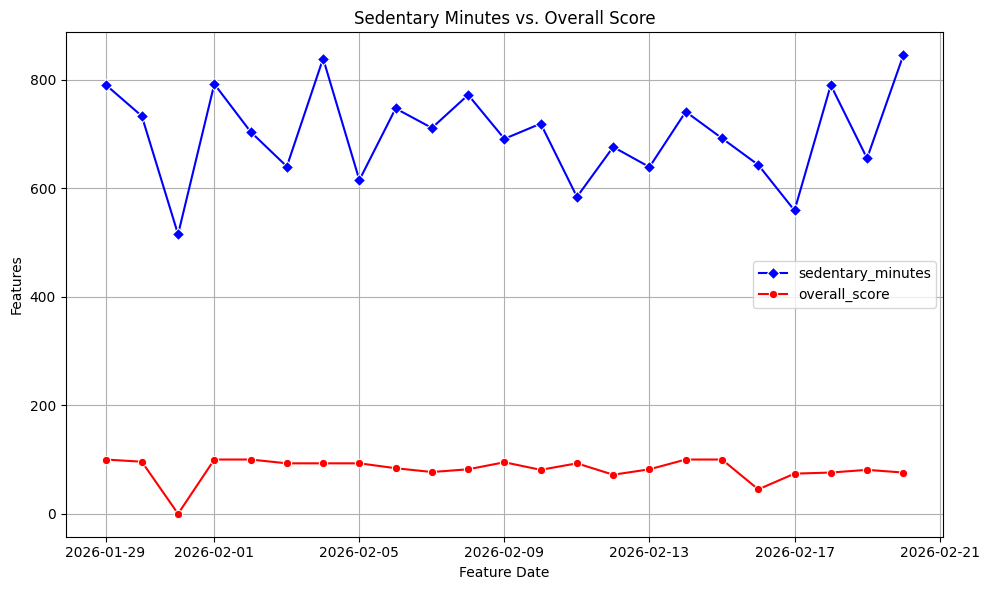

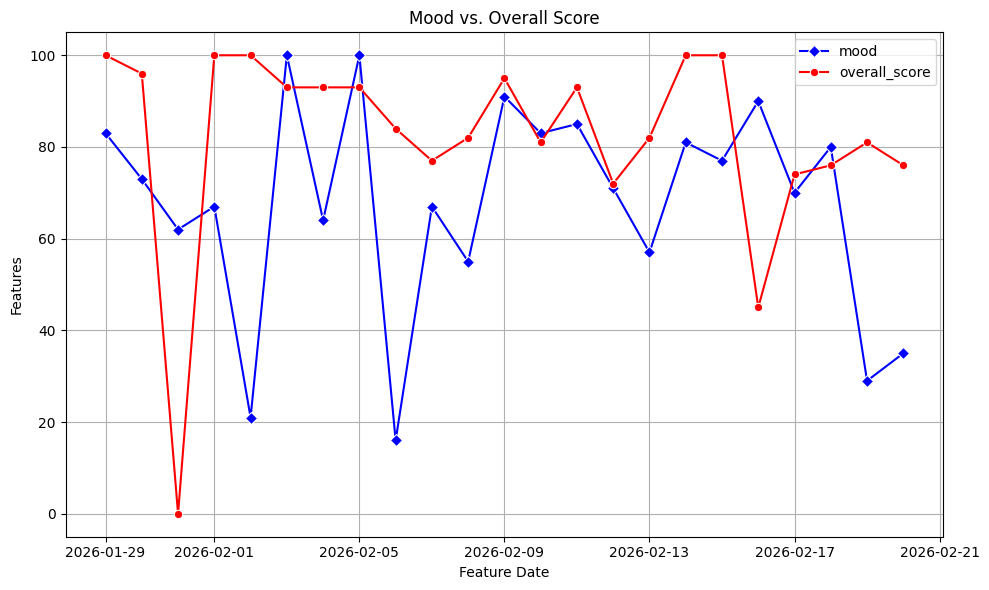

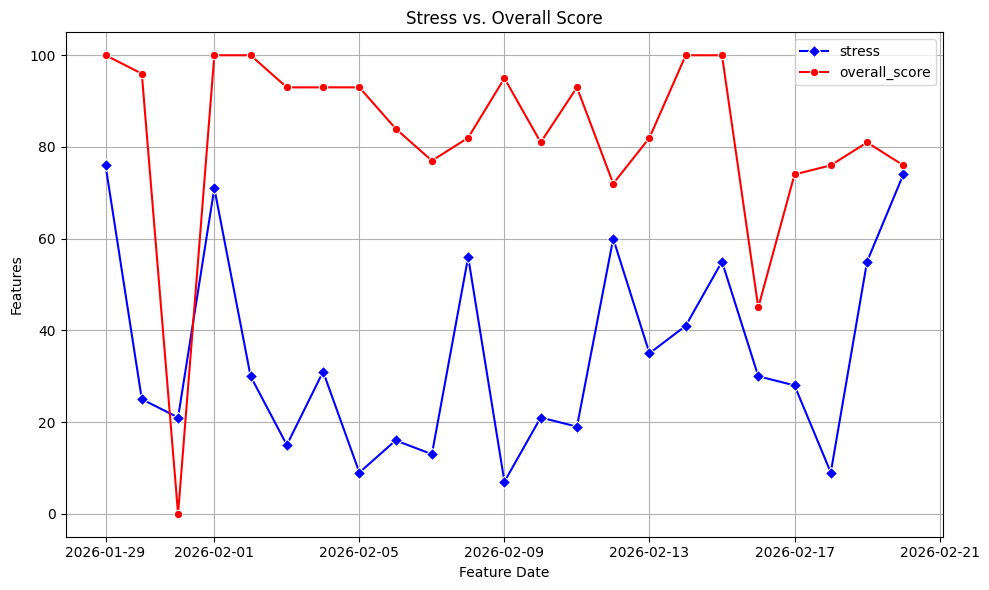

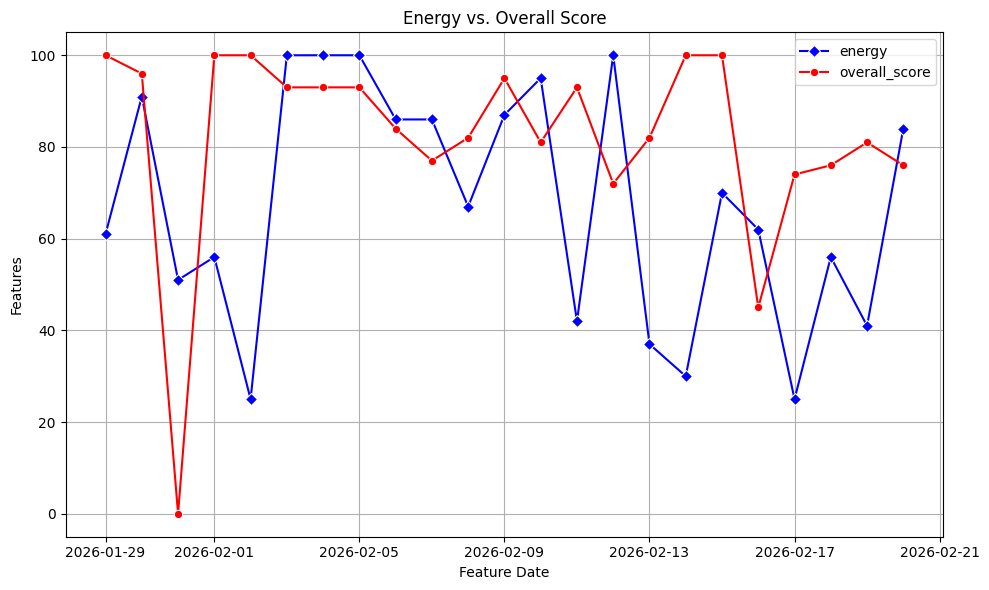

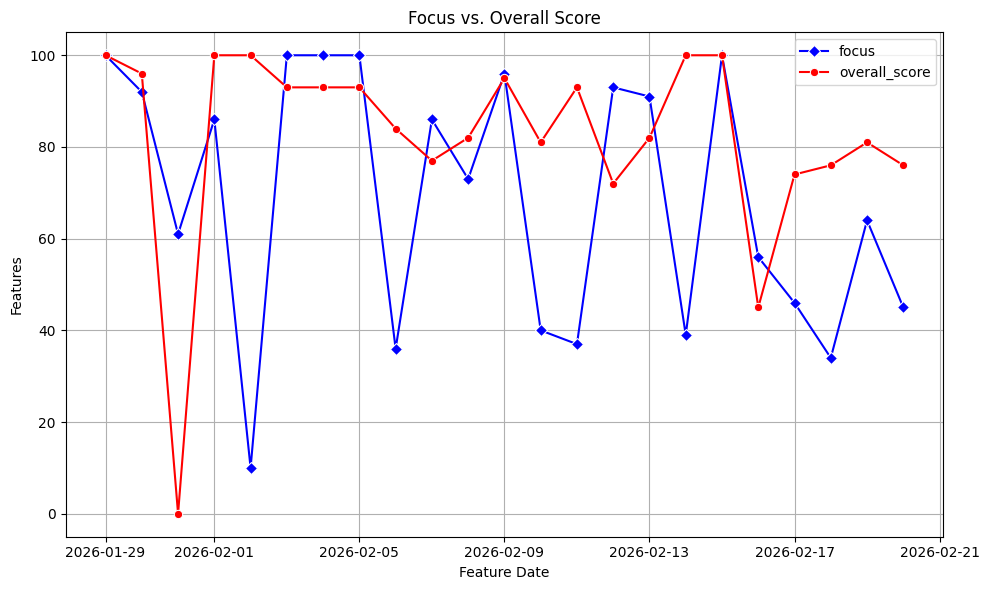

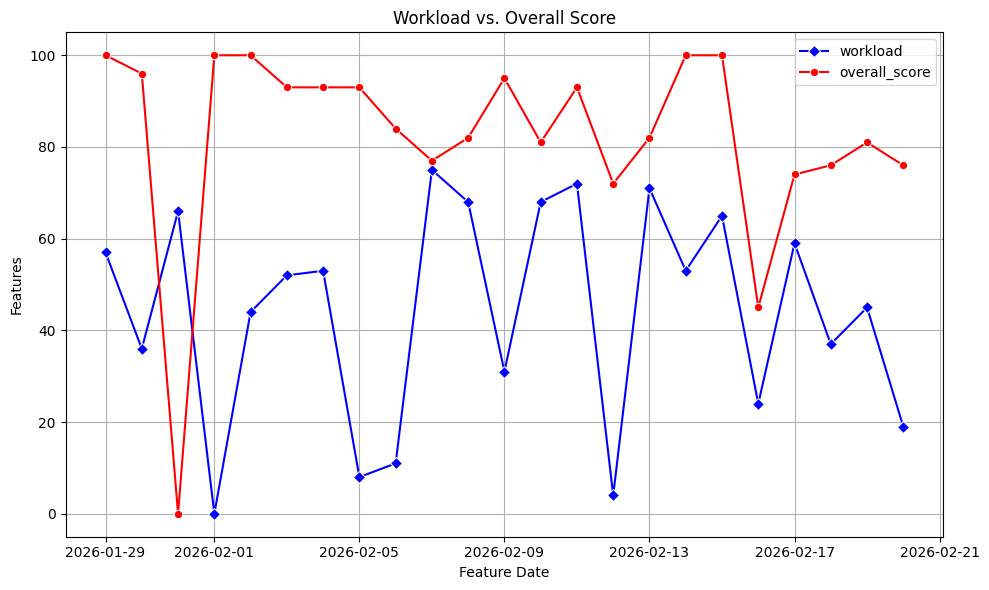

Skipping plot for sleep_restfulness vs overall_score: one or both features not found in the feature matrix.


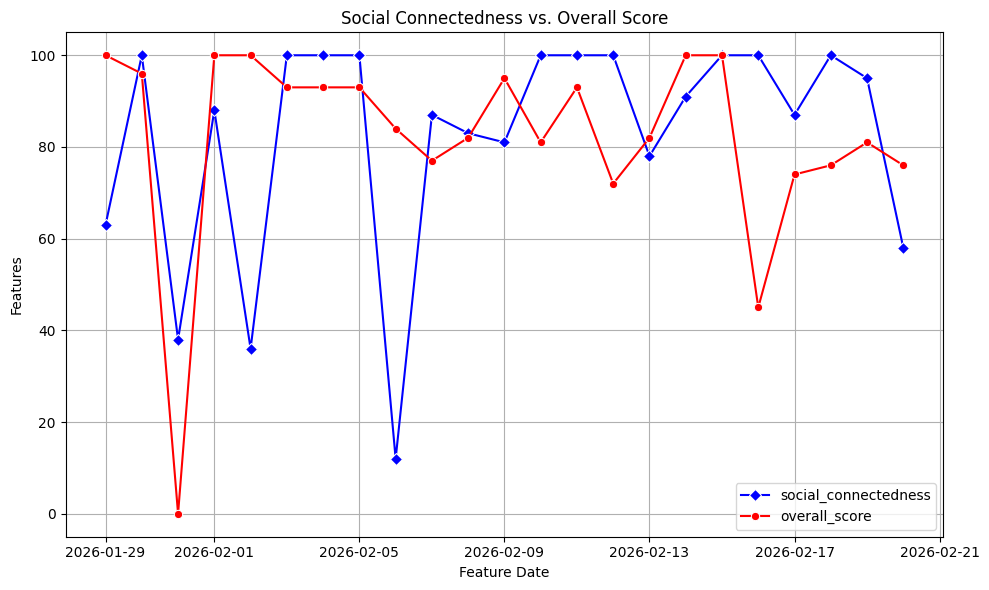

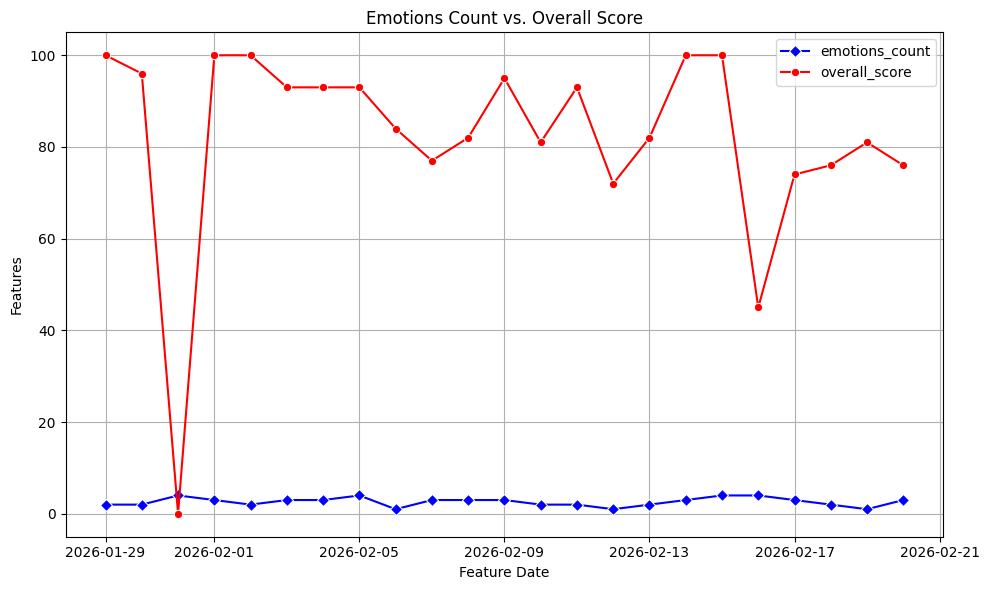

Skipping plot for bedtime_consistency_score vs overall_score: one or both features not found in the feature matrix.
Skipping plot for journal_word_count vs overall_score: one or both features not found in the feature matrix.
Correlation Matrix for Requested Features:


,activity_calories,blood_oxygen_avg,breakfast_logged,breathing_rate,caffeine_cups,calories_out,daily_checkin_streak,deep_ratio,dinner_logged,distance_total_km,...,social_connectedness,steps,steps_vs_7d,stress,stress_volatility_7d,stress_vs_7d,total_water_ml,very_active_minutes,wake_ratio,workload
activity_calories,1.000000,0.149364,0.069786,-0.035349,0.265908,0.997036,0.154766,0.409373,0.155700,0.883399,...,0.186673,0.891304,0.331028,-0.174085,-0.195652,-0.291502,0.371165,0.745309,-0.196555,0.168067
blood_oxygen_avg,0.149364,1.000000,-0.149830,-0.235083,0.092920,0.154456,0.421691,0.349081,0.000000,0.233098,...,-0.015533,0.250637,0.375673,-0.284056,-0.321358,-0.221217,0.082258,-0.195820,-0.157895,-0.113186
breakfast_logged,0.069786,-0.149830,1.000000,-0.251650,NaN,0.069786,-0.180664,0.000000,0.796819,0.162835,...,0.169953,0.162835,-0.139573,-0.360919,0.116311,-0.302407,NaN,-0.371486,-0.423798,0.186189
breathing_rate,-0.035349,-0.235083,-0.251650,1.000000,0.179093,-0.061576,-0.568787,-0.440586,-0.411077,-0.091795,...,-0.040757,-0.099206,-0.202974,0.580215,0.461823,0.787380,-0.375673,0.328909,0.475171,-0.121192
caffeine_cups,0.265908,0.092920,NaN,0.179093,1.000000,0.246915,-0.514286,-0.318258,-0.432049,0.170941,...,-0.152821,0.189934,-0.455842,-0.209132,0.520420,0.417855,0.038362,0.478618,0.092815,-0.152046


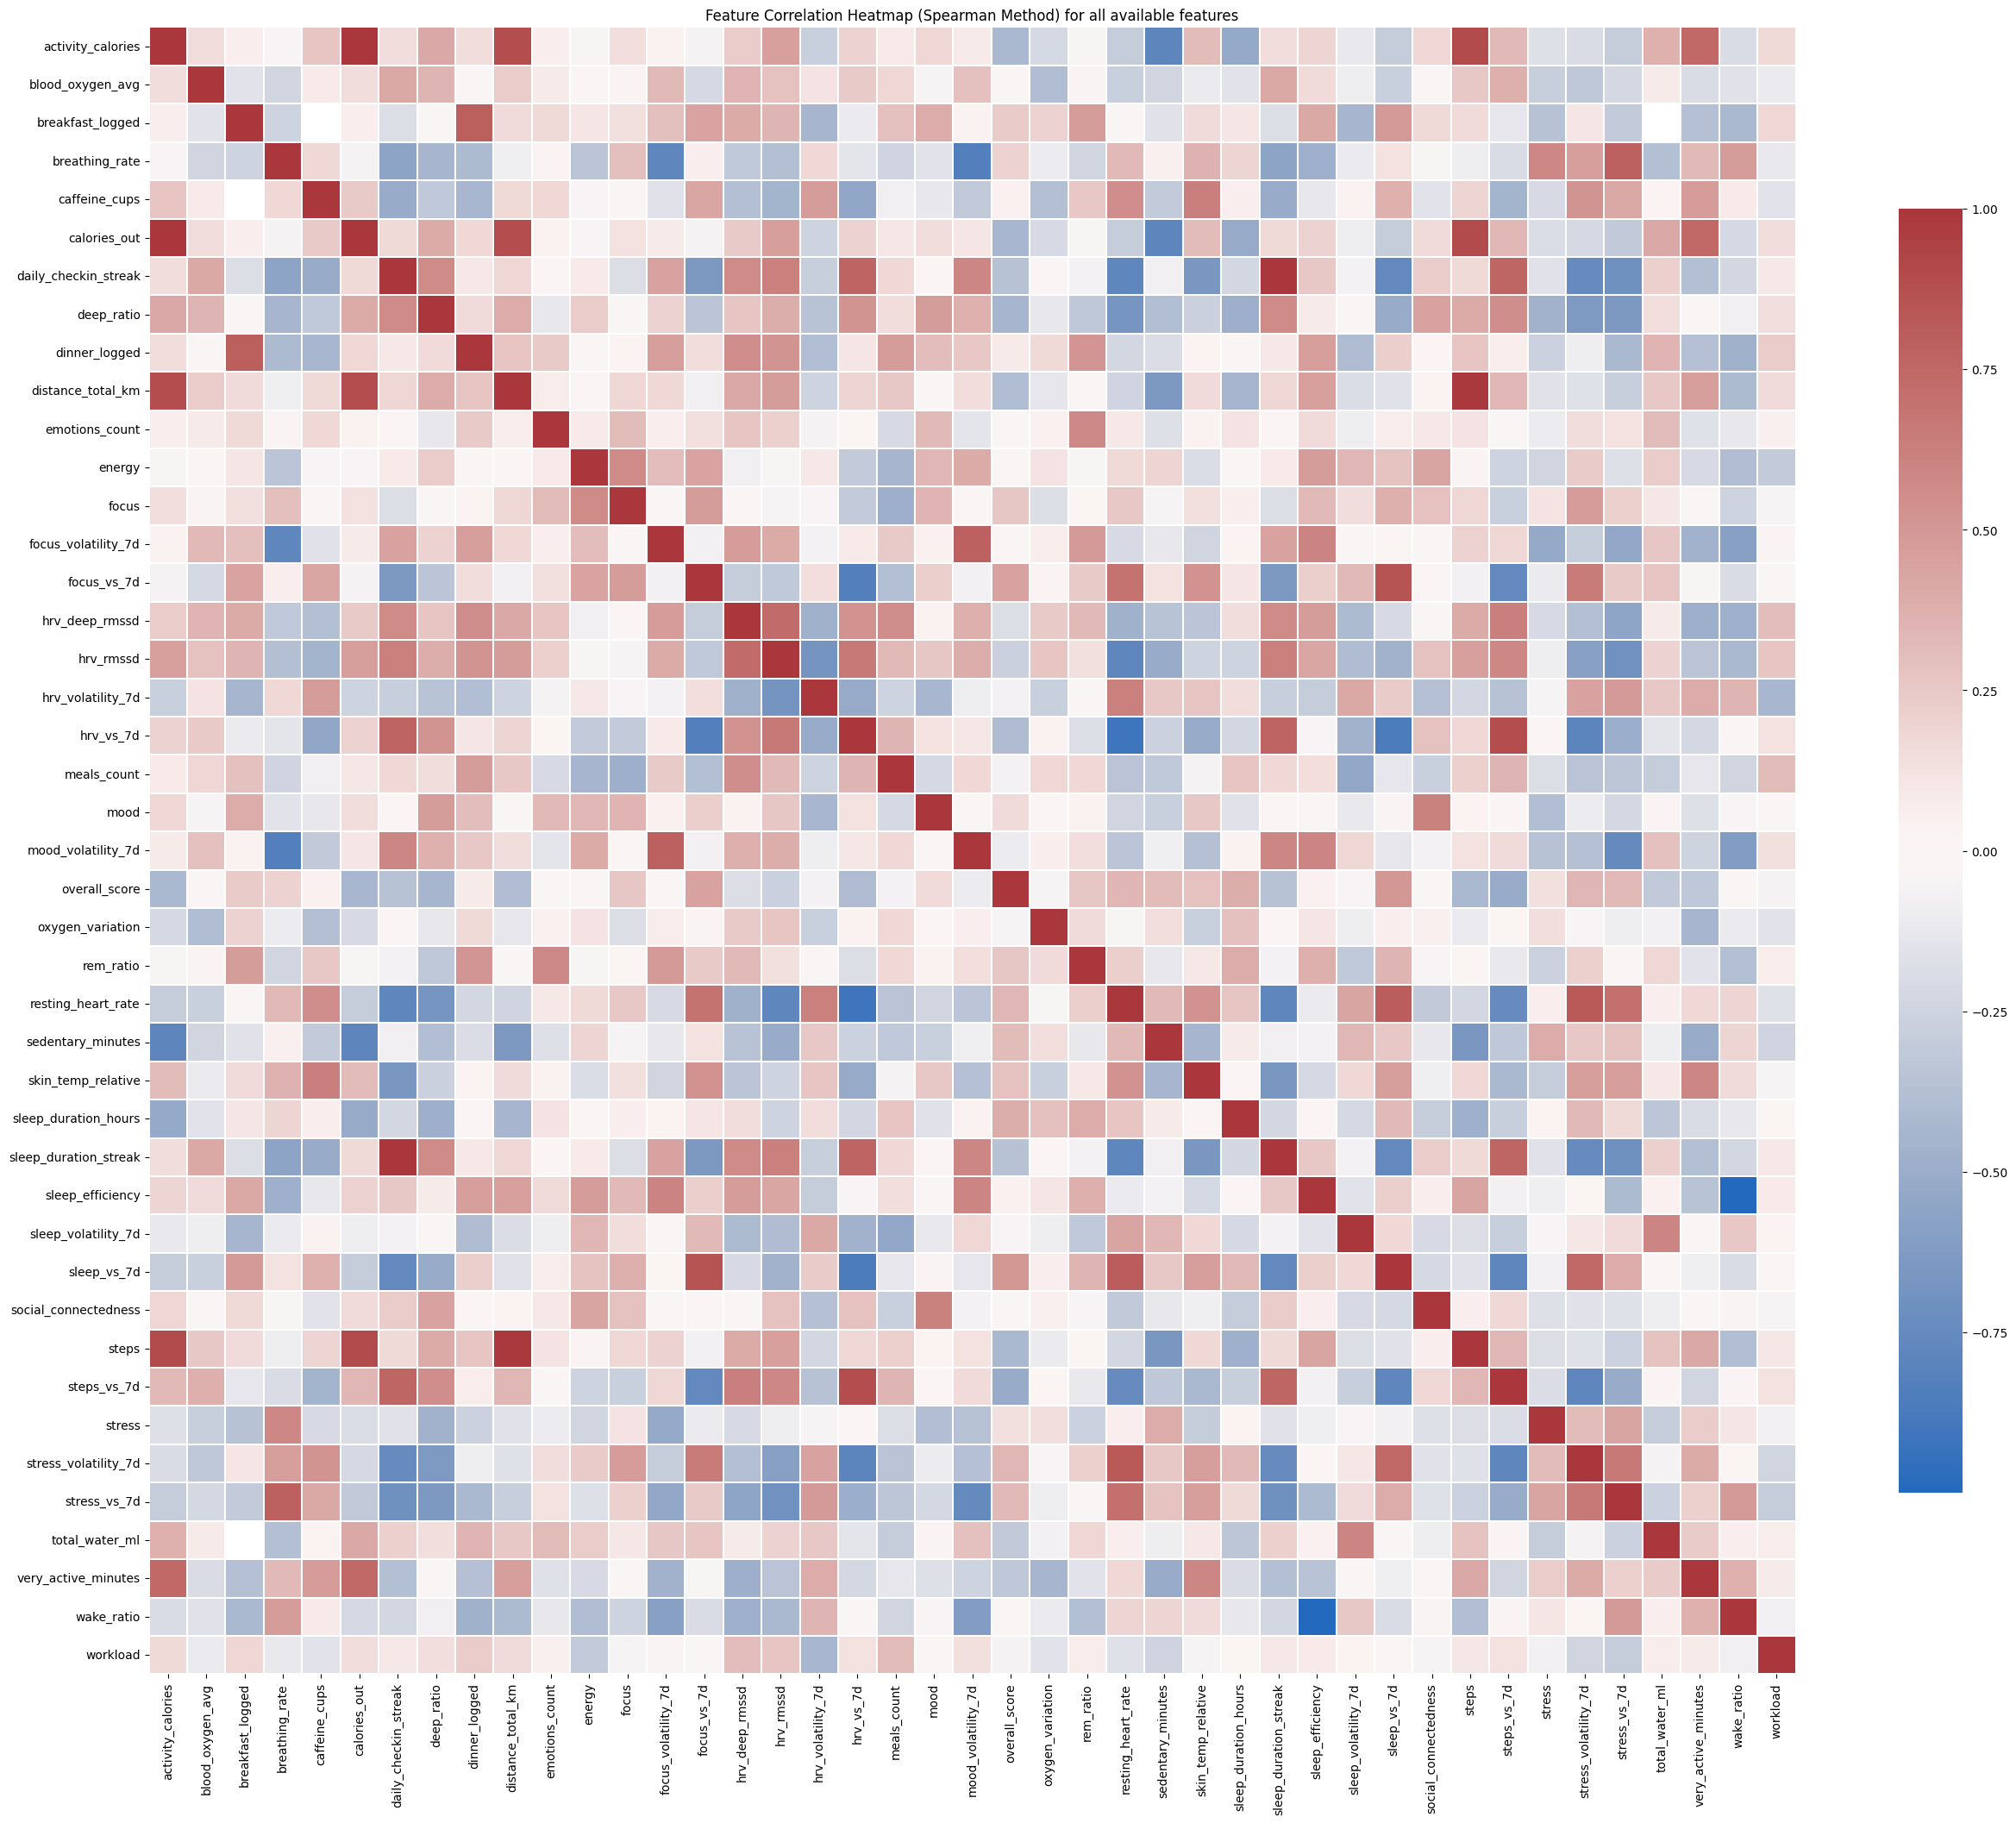

In [ ]:
User_id = ["ba7806f0-d26f-4b9d-95d7-917d4159b638","bf8434ee-b495-4da4-96d0-d919c5b4a957"]

for user_id, keys in zip(User_id, all_feature_matrices.keys()):
  print (f"{user_id} and {keys}")
  get_plots_all(all_feature_matrices[keys], user_id, False)

# CLUSTERING

### Aggregating Features by Category for Clustering Analysis

To prepare for clustering, we'll aggregate the numerous features into the four broader categories: Sleep & Recovery, Activity & Physiology, Nutrition & Hydration, and Mental & Behavioral. For each user, we will calculate the average value for features within each category.

This will reduce the dimensionality and provide a high-level overview of each user's profile across these key domains, making it easier to visualize potential clusters.

### Clustering Approach: Per-User Daily Analysis

To identify 'good', 'bad', and 'mid' days for each user, we will follow these steps:

1.  **Data Preparation (Per User, Per Day):**
    *   **Handle Missing Values:** Impute `NaN` values for each feature (e.g., using the median). Since features are categorical (e.g. sleep, activity), imputation will be done within each user's data.
    *   **Feature Scaling:** Apply `StandardScaler` to features within each category (`A`, `B`, `C`, `D`) to ensure all features contribute equally to the clustering process, regardless of their original scale.
2.  **Dimensionality Reduction (Per User, Per Category):**
    *   Apply Principal Component Analysis (PCA) separately to the scaled features of each category. This will reduce the number of features within each category while retaining most of the variance.
    *   Combine the principal components from all categories into a single feature set for clustering.
3.  **Unsupervised Clustering (Per User):**
    *   Apply K-Means clustering (with `k=3` for 'good', 'bad', 'mid' days) to the combined PCA factors for each user.
4.  **Evaluation & Visualization:**
    *   Evaluate the clustering quality using metrics like Silhouette Score.
    *   Visualize the clustered days, mapping each day back to its assigned group.

In [ ]:
# Define the feature lists for each category (converting to lowercase for consistency)
category_A_features = [
    'sleep_duration_hours', 'sleep_efficiency', 'deep_ratio', 'rem_ratio',
     'hrv_rmssd', 'readiness_score',
    'bedtime_consistency_score', 'sleep_start_time_variability_7d', 'caffeine_cups'
]
category_B_features = [
    'steps', 'total_active_minutes', 'sedentary_minutes', 'sedentary_burden_score',
    'resting_heart_rate', 'breathing_rate', 'blood_oxygen_avg',
    'calories_out', 'activity_calories', 'bmr_calories'
]
category_C_features = []

category_D_features = [
    'mood', 'stress', 'energy', 'focus', 'social_connectedness', 'workload',
    'emotions_count', 'negative_emotion_ratio']

In [ ]:
processed_user_data = {}

for user_id, feature_matrix in all_feature_matrices.items():
    print(f"\nProcessing data for user: {user_id}")
    if not isinstance(feature_matrix.index, pd.DatetimeIndex):
        feature_matrix.index = pd.to_datetime(feature_matrix.index)
    scaled_features_by_category = {}

    all_category_features = {
        'A': category_A_features,
        'B': category_B_features,
        'C': category_C_features,
        'D': category_D_features
    }

    for category_name, feature_list in all_category_features.items():
        current_category_cols = [col for col in feature_list if col in feature_matrix.columns]

        if not current_category_cols:
            print(f"  No features found for Category {category_name} for user {user_id}. Skipping scaling for this category.")
            continue

        category_df = feature_matrix[current_category_cols].copy()

        # 1. Handle Missing Values: Using median imputation
        imputer = SimpleImputer(strategy='median')
        imputed_data = imputer.fit_transform(category_df)
        imputed_category_df = pd.DataFrame(imputed_data, columns=current_category_cols, index=category_df.index)
        # 2. Feature Scaling: Apply StandardScaler for features within this category
        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(imputed_category_df)
        scaled_category_df = pd.DataFrame(scaled_data, columns=current_category_cols, index=category_df.index)
        scaled_features_by_category[category_name] = scaled_category_df
        print(f"  Processed Category {category_name} for user {user_id}. Shape: {scaled_category_df.shape}")

    if scaled_features_by_category:
        processed_user_data[user_id] = scaled_features_by_category
        print(f"Stored scaled features by category for user {user_id}.")
    else:
        print(f"No categories processed for user {user_id}. Skipping storage.")

# Sample
if processed_user_data:
    sample_user_id = next(iter(processed_user_data.keys()))
    print(f"\nSample of processed and scaled daily features for user {sample_user_id} (first category):")
    first_category_name = next(iter(processed_user_data[sample_user_id].keys()))
    display(processed_user_data[sample_user_id][first_category_name].head())
else:
    print("No user data was successfully processed for clustering preparation.")


Processing data for user: ameena
  Processed Category A for user ameena. Shape: (24, 6)
  Processed Category B for user ameena. Shape: (24, 8)
  No features found for Category C for user ameena. Skipping scaling for this category.
  Processed Category D for user ameena. Shape: (24, 7)
Stored scaled features by category for user ameena.

Sample of processed and scaled daily features for user ameena (first category):


,sleep_duration_hours,sleep_efficiency,deep_ratio,rem_ratio,hrv_rmssd,caffeine_cups
feature_date,,,,,,
2026-01-29,-0.192004,-1.478471,-0.970334,-1.677031,-1.716125,-0.418121
2026-01-30,0.738337,-1.175841,-1.162444,-0.824940,-2.165700,1.588860
2026-01-31,-0.075711,0.034676,-0.394004,0.453195,-0.120137,3.595841
2026-02-01,0.883703,-0.671459,-1.311863,1.104793,-0.868897,-0.418121
2026-02-02,0.374923,0.665154,-1.290517,2.433052,-1.093853,1.588860


### Dimensionality Reduction using PCA (Per User, Per Category)

Now that the data for each user has been imputed and scaled, we will apply Principal Component Analysis (PCA) to each category (Sleep & Recovery, Activity & Physiology, Nutrition & Hydration, Mental & Behavioral) separately. This approach ensures that the principal components are derived from features within their respective domains.

After applying PCA to each category, the resulting principal components will be combined for each day for each user. This will create a consolidated feature set with reduced dimensionality, suitable for the subsequent clustering analysis.

In [ ]:
pca_transformed_user_data = {}

# Define a reasonable number of components. Adjust based on explained variance if needed.
# For now, let's keep it simple and take 2 components per category if possible.
# We can also decide on a variance threshold later.
N_COMPONENTS_PER_CATEGORY = 2

for user_id, categories_data in processed_user_data.items():
    print(f"\nApplying PCA for user: {user_id}")
    user_pca_components = []
    for category_name, scaled_df in categories_data.items():
        if scaled_df.empty:
            print(f"  Category {category_name} for user {user_id} is empty. Skipping PCA.")
            continue
        n_components_to_use = min(N_COMPONENTS_PER_CATEGORY, scaled_df.shape[1])
        if n_components_to_use == 0:
             print(f"  Category {category_name} for user {user_id} has no features. Skipping PCA.")
             continue

        pca = PCA(n_components=n_components_to_use)
        principal_components = pca.fit_transform(scaled_df)
        pc_cols = [f'PC_{category_name}_{i+1}' for i in range(n_components_to_use)]
        pc_df = pd.DataFrame(data=principal_components, columns=pc_cols, index=scaled_df.index)
        user_pca_components.append(pc_df)

        print(f"  Category {category_name} PCA applied. Original features: {scaled_df.shape[1]}, Components: {n_components_to_use}")

    if user_pca_components:
        # Using 'inner' join to ensure only dates common to all processed categories are kept
        combined_pca_df = pd.concat(user_pca_components, axis=1, join='inner')
        pca_transformed_user_data[user_id] = combined_pca_df
        print(f"Combined PCA components for user {user_id}. Total shape: {combined_pca_df.shape}")
    else:
        print(f"No PCA components generated for user {user_id}. Skipping.")

# Sample PCA
if pca_transformed_user_data:
    sample_user_id = next(iter(pca_transformed_user_data.keys()))
    print(f"\nSample of PCA-transformed daily features for user {sample_user_id}:")
    display(pca_transformed_user_data[sample_user_id].head())
else:
    print("No user data was successfully PCA-transformed.")


Applying PCA for user: ameena
  Category A PCA applied. Original features: 6, Components: 2
  Category B PCA applied. Original features: 8, Components: 2
  Category D PCA applied. Original features: 7, Components: 2
Combined PCA components for user ameena. Total shape: (24, 6)

Sample of PCA-transformed daily features for user ameena:


,PC_A_1,PC_A_2,PC_B_1,PC_B_2,PC_D_1,PC_D_2
feature_date,,,,,,
2026-01-29,-0.309458,-2.841412,-1.962582,2.701947,-0.075288,-0.727029
2026-01-30,-2.160187,-2.330555,-2.051489,2.678787,1.017615,-0.870083
2026-01-31,-1.864921,0.118943,4.518177,2.355161,-0.796806,1.410373
2026-02-01,-1.786723,-0.309760,-3.130118,1.485578,0.068915,-1.719163
2026-02-02,-2.897582,1.003513,0.037408,0.616649,-3.902197,0.750752


### Unsupervised Clustering using K-Means (Per User)

With the dimensionality of our daily features reduced through PCA, we can now apply K-Means clustering to each user's data. Our goal is to categorize each day into three groups: 'good', 'bad', and 'mid' days. K-Means is suitable for this task as it will partition the data points (days) into `k` clusters based on their feature similarity.

After clustering, we'll assign a label to each day indicating its cluster membership. We will also compute the Silhouette Score to evaluate the quality of the clustering.


Applying K-Means clustering for user: ameena
  Silhouette Score for user ameena: 0.31
  Generating cluster visualization for user ameena...


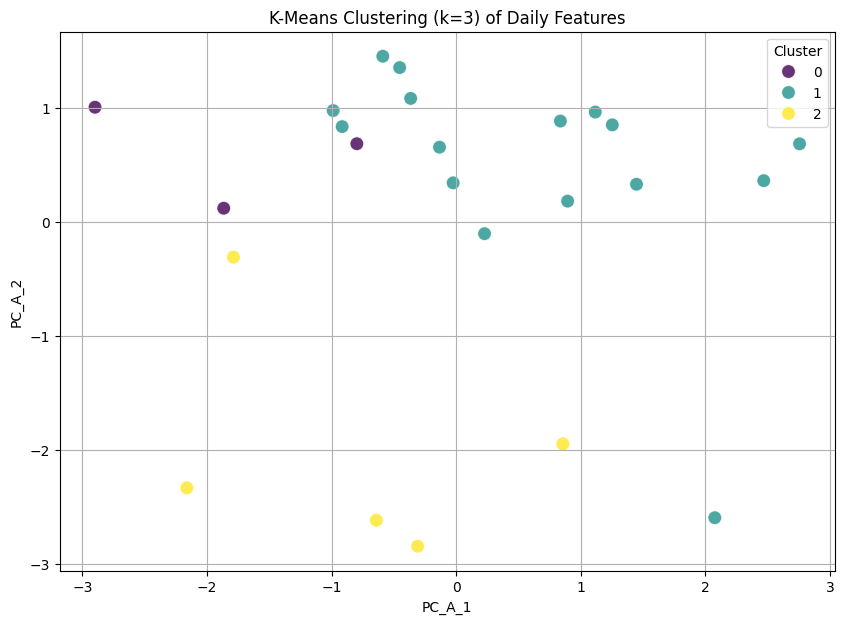


Sample of clustered daily features for user ameena:


,PC_A_1,PC_A_2,PC_B_1,PC_B_2,PC_D_1,PC_D_2,cluster
feature_date,,,,,,,
2026-01-29,-0.309458,-2.841412,-1.962582,2.701947,-0.075288,-0.727029,2
2026-01-30,-2.160187,-2.330555,-2.051489,2.678787,1.017615,-0.870083,2
2026-01-31,-1.864921,0.118943,4.518177,2.355161,-0.796806,1.410373,0
2026-02-01,-1.786723,-0.309760,-3.130118,1.485578,0.068915,-1.719163,2
2026-02-02,-2.897582,1.003513,0.037408,0.616649,-3.902197,0.750752,0


In [ ]:
clustering_results = {}

# Number of clusters (for 'good', 'bad', 'mid' days)
K = 3

for user_id, pca_df in pca_transformed_user_data.items():
    print(f"\nApplying K-Means clustering for user: {user_id}")

    if pca_df.empty:
        print(f"  PCA-transformed data for user {user_id} is empty. Skipping clustering.")
        continue
    if pca_df.shape[0] < K or pca_df.shape[1] == 0:
        print(f"  Not enough data points ({pca_df.shape[0]}) or features ({pca_df.shape[1]}) for K-Means (k={K}) for user {user_id}. Skipping clustering.")
        continue

    # Apply K-Means clustering
    kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(pca_df)
    clustered_df = pca_df.copy()
    clustered_df['cluster'] = cluster_labels

    # Evaluate clustering quality using Silhouette Score
    try:
        silhouette_avg = silhouette_score(pca_df, cluster_labels)
        print(f"  Silhouette Score for user {user_id}: {silhouette_avg:.2f}")
    except Exception as e:
        silhouette_avg = None
        print(f"  Could not calculate Silhouette Score for user {user_id}: {e}")

    clustering_results[user_id] = {
        'clustered_df': clustered_df,
        'kmeans_model': kmeans,
        'silhouette_score': silhouette_avg
    }

    print(f"  Generating cluster visualization for user {user_id}...")
    plt.figure(figsize=(10, 7))
    sns.scatterplot(
        x=clustered_df.iloc[:, 0],
        y=clustered_df.iloc[:, 1],
        hue='cluster',
        palette='viridis',
        s=100,
        alpha=0.8,
        data=clustered_df
    )

    #plt.title(f'K-Means Clustering (k={K}) of Daily Features for {user_id}')
    plt.title(f'K-Means Clustering (k={K}) of Daily Features')
    plt.xlabel(clustered_df.columns[0])
    plt.ylabel(clustered_df.columns[1])
    plt.legend(title='Cluster')
    plt.grid(True)
    plt.show()


#Sample of clustered data
if clustering_results:
    sample_user_id = next(iter(clustering_results.keys()))
    print(f"\nSample of clustered daily features for user {sample_user_id}:")
    display(clustering_results[sample_user_id]['clustered_df'].head())
else:
    print("No user data was successfully clustered.")


Generating 3D cluster visualization for user: ameena


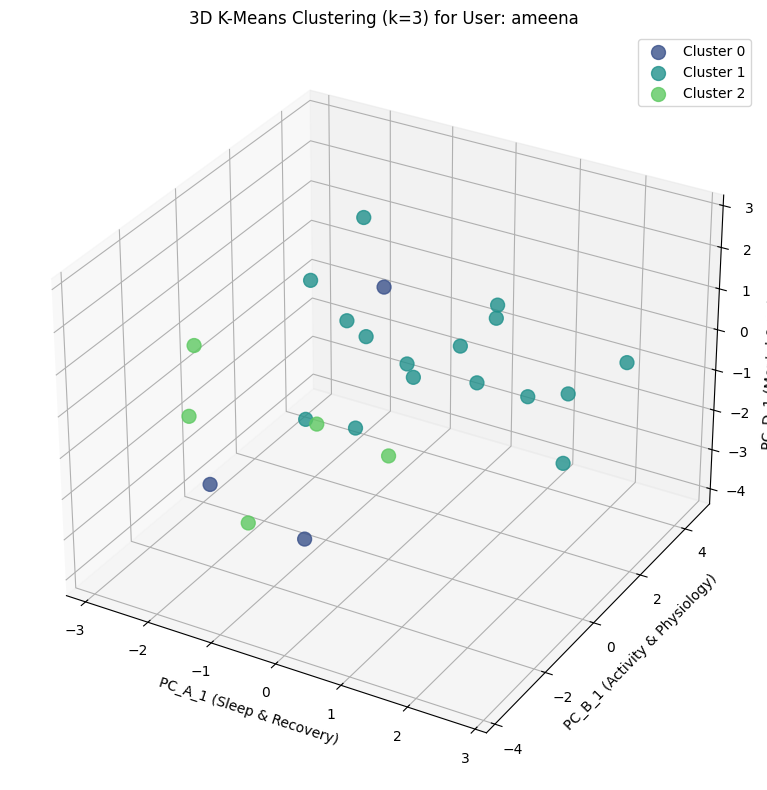

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

for user_id, cluster_data in clustering_results.items():
    print(f"\nGenerating 3D cluster visualization for user: {user_id}")

    clustered_df = cluster_data['clustered_df']
    pc_cols_for_3d = ['PC_A_1', 'PC_B_1', 'PC_D_1']
    if not all(col in clustered_df.columns for col in pc_cols_for_3d):
        print(f"  Not enough principal components for 3D plot for user {user_id}. Requires {', '.join(pc_cols_for_3d)}.")
        continue

    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    unique_clusters = sorted(clustered_df['cluster'].unique())
    colors = sns.color_palette('viridis', n_colors=len(unique_clusters))
    color_map = dict(zip(unique_clusters, colors))

    for cluster_label in unique_clusters:
        subset = clustered_df[clustered_df['cluster'] == cluster_label]
        ax.scatter(
            subset['PC_A_1'],
            subset['PC_B_1'],
            subset['PC_D_1'],
            color=color_map[cluster_label],
            label=f'Cluster {cluster_label}',
            s=100,
            alpha=0.8
        )

    ax.set_xlabel('PC_A_1 (Sleep & Recovery)')
    ax.set_ylabel('PC_B_1 (Activity & Physiology)')
    ax.set_zlabel('PC_D_1 (Mental & Behavioral)')
    ax.set_title(f'3D K-Means Clustering (k={K}) for User: {user_id}')
    ax.legend()
    plt.tight_layout()
    plt.show()


### Interpreting Per-User Clusters: Average Feature Values


--- Analysis for User: ameena ---
Average Overall Score per Cluster:


,overall_score
cluster,
2,89.600000
1,84.066667
0,61.333333



Average values of original features for each Cluster (sorted by Overall Score if available):


,activity_calories,blood_oxygen_avg,bmr_calories,breakfast_logged,breathing_rate,caffeine_cups,calories_out,daily_checkin_streak,deep_ratio,dinner_logged,...,social_connectedness,steps,steps_vs_7d,stress,stress_volatility_7d,stress_vs_7d,total_water_ml,very_active_minutes,wake_ratio,workload
cluster,,,,,,,,,,,,,,,,,,,,,
2,912.400000,96.860000,1475.0,0.800000,18.040000,0.250000,2190.600000,5.200000,22.020000,0.600000,...,81.800000,7314.400000,10964.600000,51.000000,24.696000,43.56,850.000000,NaN,17.520000,29.800000
1,1649.466667,97.378571,1475.0,0.933333,17.213333,0.071429,2790.800000,7.933333,26.146667,0.933333,...,93.466667,14330.866667,13413.066667,31.666667,19.574000,30.78,1067.857143,44.333333,9.686667,49.866667
0,1830.333333,97.333333,1475.0,1.000000,17.333333,1.000000,2950.333333,6.000000,20.066667,1.000000,...,28.666667,15742.666667,12340.000000,22.333333,23.063333,35.90,1283.333333,62.000000,8.700000,40.333333



Minimum values of original features for each Cluster (sorted by Overall Score if available):


,activity_calories,blood_oxygen_avg,bmr_calories,breakfast_logged,breathing_rate,caffeine_cups,calories_out,daily_checkin_streak,deep_ratio,dinner_logged,...,social_connectedness,steps,steps_vs_7d,stress,stress_volatility_7d,stress_vs_7d,total_water_ml,very_active_minutes,wake_ratio,workload
cluster,,,,,,,,,,,,,,,,,,,,,
2,559.0,96.5,1475.0,0.0,17.2,0.0,1905.0,2.0,18.3,0.0,...,58.0,3821.0,8552.0,9.0,17.18,34.6,350.0,NaN,14.0,0.0
1,1036.0,95.4,1475.0,0.0,16.2,0.0,2263.0,7.0,18.8,0.0,...,78.0,9070.0,11621.0,7.0,15.01,21.0,500.0,10.0,5.0,4.0
0,1066.0,97.1,1475.0,1.0,17.0,0.0,2327.0,4.0,18.4,1.0,...,12.0,10713.0,11538.0,16.0,19.23,27.2,350.0,16.0,7.4,11.0



Maximum values of original features for each Cluster (sorted by Overall Score if available):


,activity_calories,blood_oxygen_avg,bmr_calories,breakfast_logged,breathing_rate,caffeine_cups,calories_out,daily_checkin_streak,deep_ratio,dinner_logged,...,social_connectedness,steps,steps_vs_7d,stress,stress_volatility_7d,stress_vs_7d,total_water_ml,very_active_minutes,wake_ratio,workload
cluster,,,,,,,,,,,,,,,,,,,,,
2,1253.0,97.3,1475.0,1.0,18.8,1.0,2483.0,8.0,30.1,1.0,...,100.0,9404.0,14023.0,76.0,31.82,53.5,1050.0,NaN,21.0,57.0
1,2209.0,98.6,1475.0,1.0,18.4,1.0,3230.0,8.0,35.1,1.0,...,100.0,19020.0,14818.0,60.0,25.04,39.1,1500.0,99.0,18.9,75.0
0,2888.0,97.5,1475.0,1.0,17.8,2.0,3819.0,8.0,22.6,1.0,...,38.0,22341.0,13351.0,30.0,25.50,42.3,2250.0,121.0,10.6,66.0



Standard Deviations of original features for each Cluster (sorted by Overall Score if available):


,activity_calories,blood_oxygen_avg,bmr_calories,breakfast_logged,breathing_rate,caffeine_cups,calories_out,daily_checkin_streak,deep_ratio,dinner_logged,...,social_connectedness,steps,steps_vs_7d,stress,stress_volatility_7d,stress_vs_7d,total_water_ml,very_active_minutes,wake_ratio,workload
cluster,,,,,,,,,,,,,,,,,,,,,
2,271.995956,0.304959,0.0,0.447214,0.712741,0.500000,225.282711,2.774887,4.830838,0.547723,...,20.129580,2262.513602,2375.642924,31.599051,5.949826,6.853685,336.650165,NaN,2.574296,21.417283
1,376.702396,0.826651,0.0,0.258199,0.557887,0.267261,318.661307,0.258199,4.575067,0.258199,...,8.184189,2994.263775,871.799491,18.168523,3.187072,6.444067,254.654474,23.519173,4.100848,23.095660
0,945.755959,0.208167,0.0,0.000000,0.416333,1.000000,775.665736,2.000000,2.230097,0.000000,...,14.468356,5970.605692,924.393315,7.094599,3.360243,7.808329,950.438495,53.693575,1.682260,27.682726


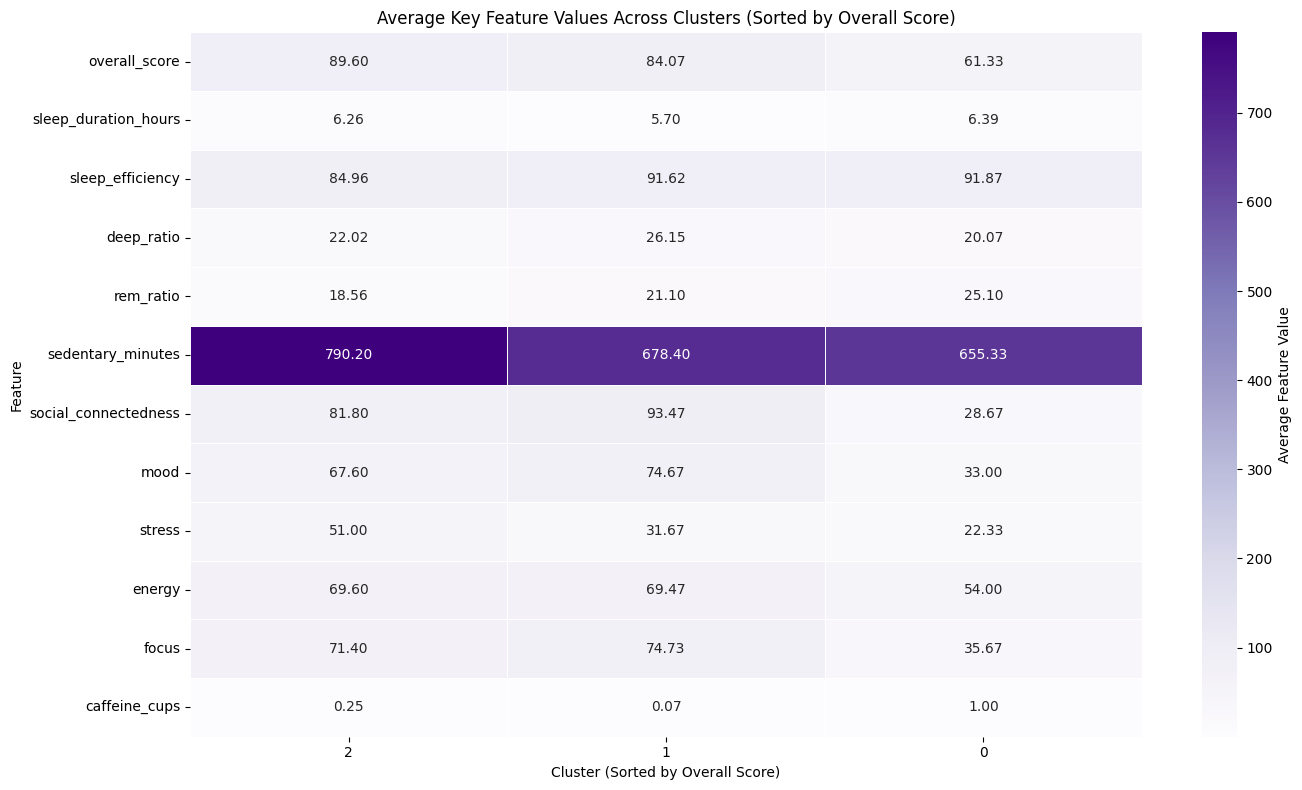

In [ ]:
# Define the key features for visualization (same as global, or customized)
key_features_for_viz_per_user = [
    'overall_score', 'readiness_score', 'sleep_duration_hours', 'sleep_efficiency', 'deep_ratio', 'rem_ratio',
    'total_active_minutes', 'sedentary_minutes','social_connectedness',
    'mood', 'stress', 'energy', 'focus','caffeine_cups', 'negative_emotion_ratio'
]


for user_id, cluster_data in clustering_results.items():
    print(f"\n--- Analysis for User: {user_id} ---")

    clustered_df_user = cluster_data['clustered_df']
    original_feature_matrix_user = all_feature_matrices[user_id]
    merged_data_for_interpretation = original_feature_matrix_user.merge(
        clustered_df_user[['cluster']],
        left_index=True,
        right_index=True,
        how='inner'
    )

    cluster_feature_means_per_user = merged_data_for_interpretation.groupby('cluster').mean()
    cluster_feature_mins_per_user = merged_data_for_interpretation.groupby('cluster').min()
    cluster_feature_maxs_per_user = merged_data_for_interpretation.groupby('cluster').max()
    cluster_feature_stds_per_user = merged_data_for_interpretation.groupby('cluster').std()

    if 'overall_score' in cluster_feature_means_per_user.columns:
        print("Average Overall Score per Cluster:")
        display(cluster_feature_means_per_user[['overall_score']].sort_values(by='overall_score', ascending=False))
        sorted_cluster_ids_user = cluster_feature_means_per_user['overall_score'].sort_values(ascending=False).index.tolist()
        cluster_feature_means_per_user_sorted = cluster_feature_means_per_user.loc[sorted_cluster_ids_user]
        cluster_feature_mins_per_user_sorted = cluster_feature_mins_per_user.loc[sorted_cluster_ids_user]
        cluster_feature_maxs_per_user_sorted = cluster_feature_maxs_per_user.loc[sorted_cluster_ids_user]
        cluster_feature_stds_per_user_sorted = cluster_feature_stds_per_user.loc[sorted_cluster_ids_user]
    else:
        cluster_feature_means_per_user_sorted = cluster_feature_means_per_user
        cluster_feature_mins_per_user_sorted = cluster_feature_mins_per_user
        cluster_feature_maxs_per_user_sorted = cluster_feature_maxs_per_user
        cluster_feature_stds_per_user_sorted = cluster_feature_stds_per_user

    print("\nAverage values of original features for each Cluster (sorted by Overall Score if available):")
    display(cluster_feature_means_per_user_sorted)

    print("\nMinimum values of original features for each Cluster (sorted by Overall Score if available):")
    display(cluster_feature_mins_per_user_sorted)

    print("\nMaximum values of original features for each Cluster (sorted by Overall Score if available):")
    display(cluster_feature_maxs_per_user_sorted)

    print("\nStandard Deviations of original features for each Cluster (sorted by Overall Score if available):")
    display(cluster_feature_stds_per_user_sorted)

    # Visualize the average feature values for key features
    key_features_for_viz_existing_user = [f for f in key_features_for_viz_per_user if f in cluster_feature_means_per_user_sorted.columns]

    if key_features_for_viz_existing_user:
        plt.figure(figsize=(14, 8))
        sns.heatmap(
            cluster_feature_means_per_user_sorted[key_features_for_viz_existing_user].T,
            cmap='Purples',
            annot=True,
            fmt=".2f",
            linewidths=.5,
            cbar_kws={'label': 'Average Feature Value'}
        )
        #plt.title(f'Average Key Feature Values Across Clusters for {user_id} (Sorted by Overall Score)')
        plt.title(f'Average Key Feature Values Across Clusters (Sorted by Overall Score)')
        plt.xlabel('Cluster (Sorted by Overall Score)')
        plt.ylabel('Feature')
        plt.tight_layout()
        plt.show()
    else:
        print(f"No key features selected for visualization were found in the cluster feature means for user {user_id}.")

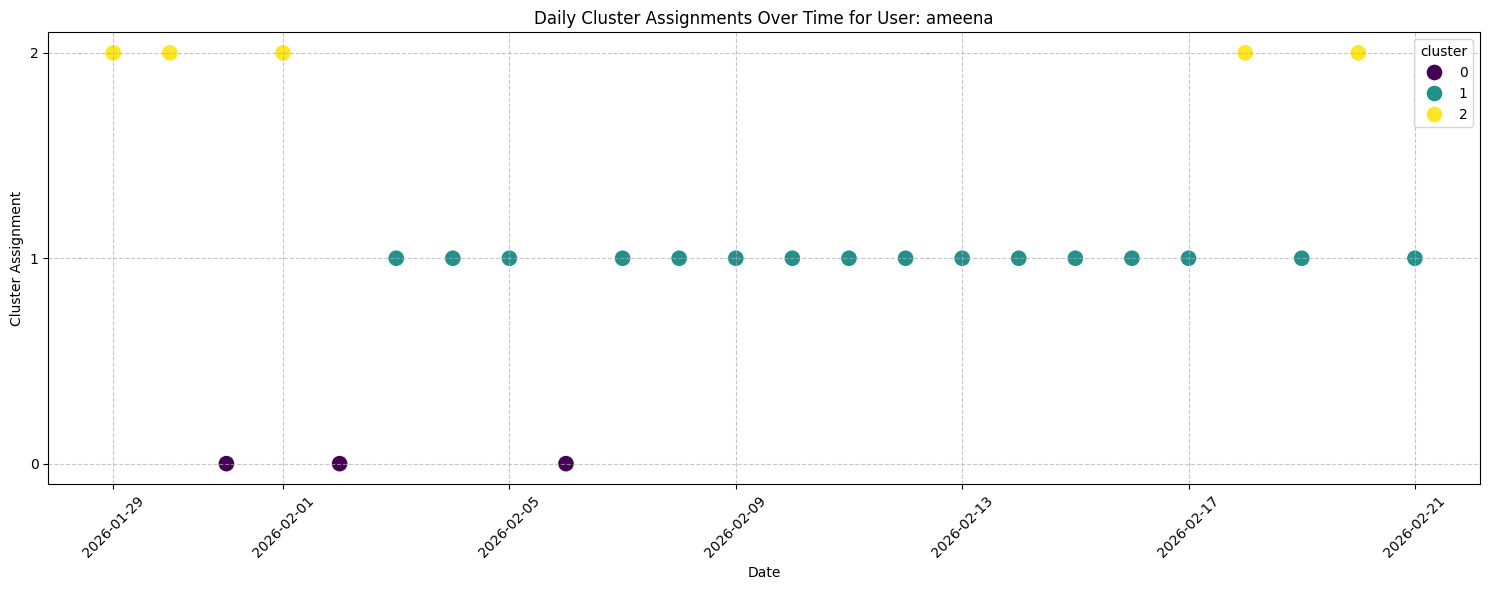

In [ ]:
# Temporal plot of clusters for each user

def plot_temporal_clusters(clustering_results, user_id):
    if user_id in clustering_results:
        clustered_df = clustering_results[user_id]['clustered_df']
        if not clustered_df.empty:
            plot_df = clustered_df.reset_index()

            plt.figure(figsize=(15, 6))
            sns.scatterplot(
                x='feature_date',
                y='cluster',
                hue='cluster',
                palette='viridis',
                s=150,
                marker='o',
                edgecolor='w',
                data=plot_df
            )
            plt.title(f'Daily Cluster Assignments Over Time for User: {user_id}')
            plt.xlabel('Date')
            plt.ylabel('Cluster Assignment')
            plt.yticks(sorted(plot_df['cluster'].unique()))
            plt.grid(True, linestyle='--', alpha=0.7)
            plt.xticks(rotation=45)
            plt.tight_layout()
            plt.show()
        else:
            print(f"No clustered data available for user {user_id}.")
    else:
        print(f"User {user_id} not found in clustering results.")

for user_id in clustering_results.keys():
    plot_temporal_clusters(clustering_results, user_id)


In [ ]:
for user_id, cluster_data in clustering_results.items():
    print(f"\nCluster assignments for user: {user_id}")
    display(cluster_data['clustered_df'][['cluster']].reset_index())


Cluster assignments for user: ameena


,feature_date,cluster
0,2026-01-29,2
1,2026-01-30,2
2,2026-01-31,0
3,2026-02-01,2
4,2026-02-02,0
5,2026-02-03,1
6,2026-02-04,1
7,2026-02-05,1
8,2026-02-06,0
9,2026-02-07,1
